# Tarea: Lógica Difusa y Algoritmos de Adaptación Social

| Campo | Detalle |
|---|---|
| **Materia** | Computación Bioinspirada — MIA-B |
| **Docente** | Marcelo Guato Burgos, PhD |
| **Alumnos** | Jorge Quizamanchuro / Cesar Araujo Abarca / Robinson Chiluisa Gallardo |
| **Fecha** | Abril 2026 |
| **Revisión** | Rev. Abril 2026 |

---

## Objetivo
Aplicar conocimientos teóricos de **Lógica Difusa** y **algoritmos de adaptación social** en implementaciones informáticas mediante Python.

## Estructura
- **PARTE 1 (50%):** Lógica Difusa
  - Problema 1: Control de derrape vehicular — Caso A (tracción delantera) y Caso B (tracción trasera)
  - Problema 2: Aplicación en entorno laboral propio
- **PARTE 2 (50%):** PSO — Optimización de formación de flota de drones

In [3]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# Si no están instaladas, ejecutar en terminal:
# pip install scikit-fuzzy numpy matplotlib jupyter

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import warnings
warnings.filterwarnings('ignore')

print('✓ Librerías cargadas correctamente')
print(f'  numpy   : {np.__version__}')
print(f'  skfuzzy : OK')
print(f'  matplotlib: OK')

✓ Librerías cargadas correctamente
  numpy   : 2.0.2
  skfuzzy : OK
  matplotlib: OK


---
# PARTE 1 — Lógica Difusa (50%)

## Problema 1: Control de Derrape Vehicular

> *"Conducir en un día lluvioso puede ser peligroso. En caso de derrapar se debe mantener la calma y evitar movimientos bruscos. Si derrapa, puede ayudar soltar el acelerador, pisar suavemente el freno si es necesario, y girar el volante en la dirección opuesta a la del derrape. Si el derrape es leve, puede corregirlo con movimientos suaves del volante."*

### Análisis del problema

Un sistema de control difuso es ideal aquí porque las variables involucradas (ángulo de derrape, velocidad, humedad) **no tienen fronteras exactas**: no hay un punto preciso donde el derrape pasa de "leve" a "moderado". La lógica difusa modela esta ambigüedad con **grados de pertenencia** (valores entre 0 y 1).

### Diferencia entre Caso A y Caso B

| | **Caso A — Tracción Delantera** | **Caso B — Tracción Trasera** |
|---|---|---|
| ¿Qué eje impulsa? | Ruedas delanteras | Ruedas traseras |
| ¿Qué derrapa? | Cola del vehículo | Cola (más fácil de provocar) |
| **Acción principal** | Corrección del volante | **Soltar el acelerador** |
| Frenado | Muy suave o nulo | Casi nunca durante el derrape |
| Dirección del volante | Hacia el lado del derrape | Contravolante (hacia el derrape) |

---
## CASO A — Vehículo de Tracción Delantera

### Universo del Discurso
Define el rango de valores válidos para cada variable del sistema:

| Variable | Rango | Unidad | Rol |
|---|---|---|---|
| Ángulo de derrape | 0 – 45 | grados (°) | Antecedente |
| Velocidad del vehículo | 0 – 120 | km/h | Antecedente |
| Humedad de la calzada | 0 – 100 | % | Antecedente |
| Corrección del volante | 0 – 45 | grados (°) | Consecuente |
| Intensidad de frenado | 0 – 100 | % | Consecuente |

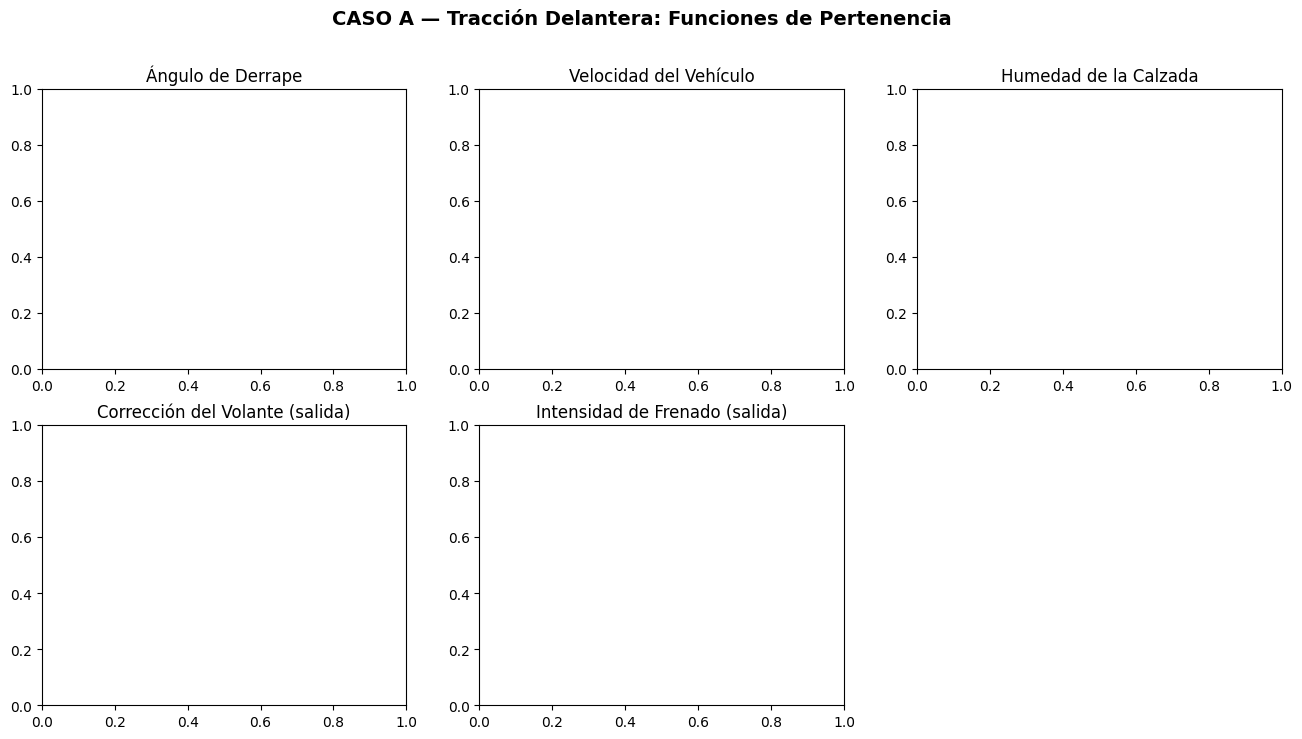

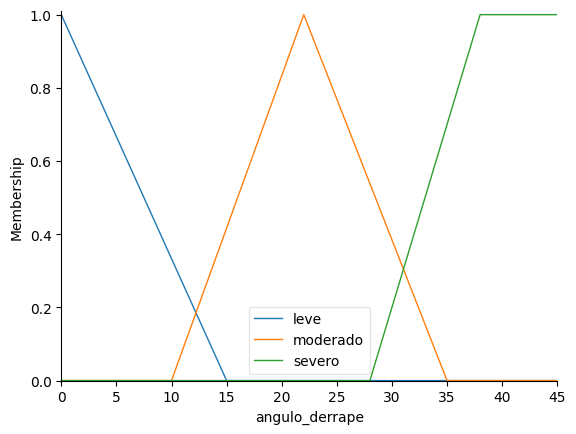

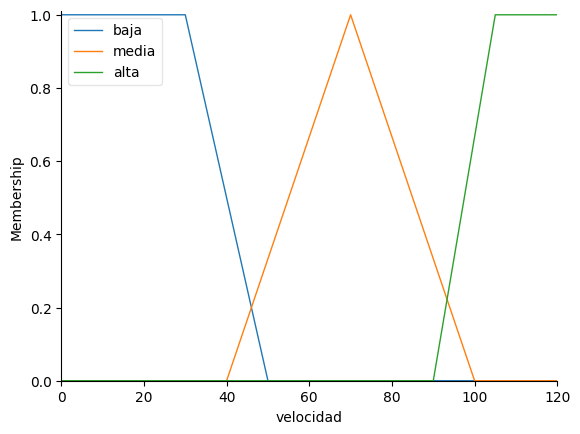

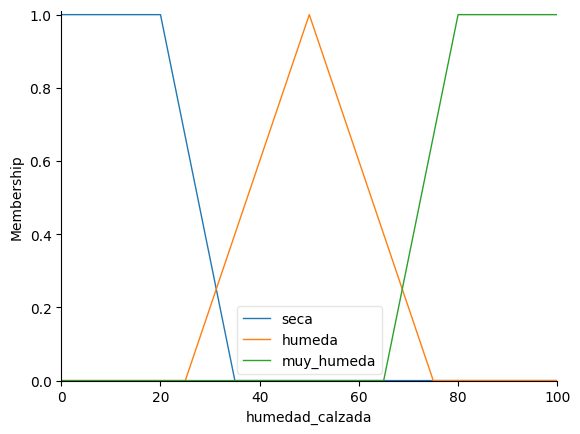

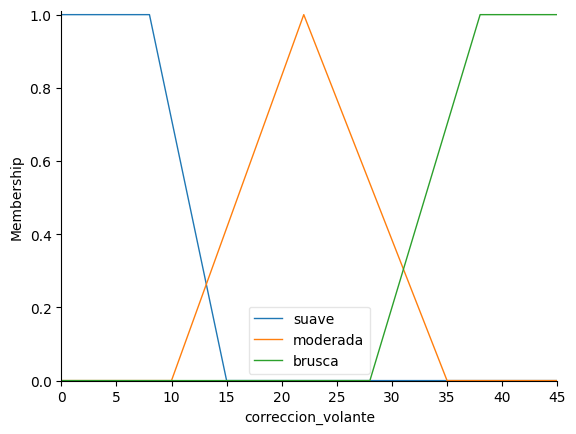

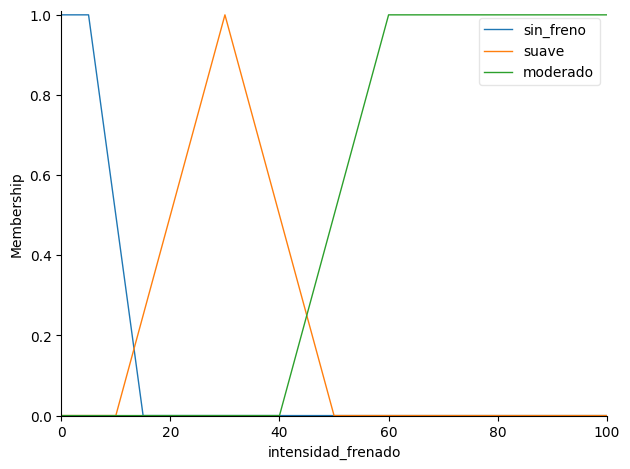

✓ Funciones de pertenencia Caso A definidas


In [4]:
# ============================================================
# CASO A: VEHÍCULO DE TRACCIÓN DELANTERA
# ============================================================

# --- PASO 1: DEFINICIÓN DE UNIVERSOS DE DISCURSO ---
# Cada universo define el rango numérico válido de la variable

angulo_range     = np.arange(0, 46, 1)    # Ángulo derrape: 0° (recto) a 45° (derrape severo)
velocidad_range  = np.arange(0, 121, 1)   # Velocidad: 0 a 120 km/h
humedad_range    = np.arange(0, 101, 1)   # Humedad calzada: 0% (seca) a 100% (charcos)
correccion_range = np.arange(0, 46, 1)    # Corrección volante: 0° (nada) a 45° (máximo giro)
frenado_range    = np.arange(0, 101, 1)   # Frenado: 0% (sin freno) a 100% (freno máximo)

# --- PASO 2: VARIABLES LINGÜÍSTICAS ---
# Antecedentes (entradas del sistema)
angulo    = ctrl.Antecedent(angulo_range,    'angulo_derrape')
velocidad = ctrl.Antecedent(velocidad_range, 'velocidad')
humedad   = ctrl.Antecedent(humedad_range,   'humedad_calzada')

# Consecuentes (salidas del sistema)
correccion = ctrl.Consequent(correccion_range, 'correccion_volante')
frenado    = ctrl.Consequent(frenado_range,    'intensidad_frenado')

# --- PASO 3: FUNCIONES DE PERTENENCIA ---
# trimf  = triangular: útil para estados de transición con pico claro
# trapmf = trapezoidal: útil para estados estables con un rango fijo

# Ángulo de derrape
angulo['leve']     = fuzz.trimf(angulo.universe,  [0, 0, 15])       # 0°–15°: derrape leve
angulo['moderado'] = fuzz.trimf(angulo.universe,  [10, 22, 35])     # 10°–35°: derrape moderado
angulo['severo']   = fuzz.trapmf(angulo.universe, [28, 38, 45, 45]) # 28°–45°: derrape severo

# Velocidad
velocidad['baja']  = fuzz.trapmf(velocidad.universe, [0, 0, 30, 50])      # < 50 km/h
velocidad['media'] = fuzz.trimf(velocidad.universe,  [40, 70, 100])       # 40–100 km/h
velocidad['alta']  = fuzz.trapmf(velocidad.universe, [90, 105, 120, 120]) # > 90 km/h

# Humedad de la calzada
humedad['seca']       = fuzz.trapmf(humedad.universe, [0, 0, 20, 35])      # Calzada seca
humedad['humeda']     = fuzz.trimf(humedad.universe,  [25, 50, 75])        # Calzada húmeda
humedad['muy_humeda'] = fuzz.trapmf(humedad.universe, [65, 80, 100, 100])  # Charcos / lluvia

# Corrección del volante (en TD: girar hacia el lado del derrape)
correccion['suave']    = fuzz.trapmf(correccion.universe, [0, 0, 8, 15])    # 0°–15°
correccion['moderada'] = fuzz.trimf(correccion.universe,  [10, 22, 35])     # 10°–35°
correccion['brusca']   = fuzz.trapmf(correccion.universe, [28, 38, 45, 45]) # 28°–45°

# Frenado (en TD: NUNCA brusco, riesgo de bloquear ruedas directrices)
frenado['sin_freno'] = fuzz.trapmf(frenado.universe, [0, 0, 5, 15])      # 0–15%: casi nada
frenado['suave']     = fuzz.trimf(frenado.universe,  [10, 30, 50])        # 10–50%: suave
frenado['moderado']  = fuzz.trapmf(frenado.universe, [40, 60, 100, 100]) # 40–100%: moderado

# --- Visualización de funciones de pertenencia ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('CASO A — Tracción Delantera: Funciones de Pertenencia',
             fontsize=14, fontweight='bold')

angulo.view(ax=axes[0, 0]);    axes[0, 0].set_title('Ángulo de Derrape')
velocidad.view(ax=axes[0, 1]); axes[0, 1].set_title('Velocidad del Vehículo')
humedad.view(ax=axes[0, 2]);   axes[0, 2].set_title('Humedad de la Calzada')
correccion.view(ax=axes[1, 0]); axes[1, 0].set_title('Corrección del Volante (salida)')
frenado.view(ax=axes[1, 1]);   axes[1, 1].set_title('Intensidad de Frenado (salida)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
print('✓ Funciones de pertenencia Caso A definidas')

In [5]:
# --- PASO 4: REGLAS DIFUSAS — CASO A ---
# Cada regla codifica el conocimiento de un experto en conducción.
# Formato: IF (condición) THEN (acción)
# En tracción delantera la acción principal es el volante; el freno es secundario.

reglas_A = [
    # --- Derrape LEVE: correcciones pequeñas ---
    ctrl.Rule(angulo['leve'] & velocidad['baja'],
              (correccion['suave'], frenado['sin_freno'])),   # Poco derrape + lento → solo volante suave

    ctrl.Rule(angulo['leve'] & velocidad['media'],
              (correccion['suave'], frenado['suave'])),        # Leve + media → suave en ambos

    ctrl.Rule(angulo['leve'] & velocidad['alta'],
              (correccion['moderada'], frenado['suave'])),     # Leve pero rápido → más corrección

    # --- Derrape MODERADO: respuesta proporcional a humedad y velocidad ---
    ctrl.Rule(angulo['moderado'] & humedad['seca'],
              (correccion['moderada'], frenado['suave'])),     # Moderado en seco → freno suave OK

    ctrl.Rule(angulo['moderado'] & humedad['humeda'],
              (correccion['moderada'], frenado['suave'])),     # Moderado húmedo → freno suave

    ctrl.Rule(angulo['moderado'] & humedad['muy_humeda'],
              (correccion['brusca'], frenado['sin_freno'])),   # Mojado: NO frenar, solo volante

    ctrl.Rule(angulo['moderado'] & velocidad['alta'],
              (correccion['brusca'], frenado['suave'])),        # Alta velocidad requiere más corrección

    # --- Derrape SEVERO: máxima corrección, mínimo freno ---
    ctrl.Rule(angulo['severo'] & humedad['seca'],
              (correccion['brusca'], frenado['suave'])),        # Severo en seco: algo de freno tolerable

    ctrl.Rule(angulo['severo'] & humedad['humeda'],
              (correccion['brusca'], frenado['suave'])),        # Severo húmedo: freno mínimo

    ctrl.Rule(angulo['severo'] & humedad['muy_humeda'],
              (correccion['brusca'], frenado['sin_freno'])),    # Severo mojado: SIN FRENO, máx volante

    ctrl.Rule(angulo['severo'] & velocidad['alta'],
              (correccion['brusca'], frenado['sin_freno'])),    # Severo + rápido: solo volante

    # --- Combinación crítica: alta velocidad + mucha lluvia ---
    ctrl.Rule(velocidad['alta'] & humedad['muy_humeda'],
              (correccion['brusca'], frenado['sin_freno'])),    # Situación más peligrosa: SIN FRENO
]

# --- PASO 5: CONSTRUCCIÓN DEL SISTEMA DE CONTROL DIFUSO ---
sistema_A = ctrl.ControlSystem(reglas_A)
sim_A     = ctrl.ControlSystemSimulation(sistema_A)

print(f'✓ Sistema de control difuso Caso A construido')
print(f'  Total de reglas definidas: {len(reglas_A)}')
print(f'  Antecedentes : angulo_derrape, velocidad, humedad_calzada')
print(f'  Consecuentes : correccion_volante, intensidad_frenado')

✓ Sistema de control difuso Caso A construido
  Total de reglas definidas: 12
  Antecedentes : angulo_derrape, velocidad, humedad_calzada
  Consecuentes : correccion_volante, intensidad_frenado


In [6]:
# --- PASO 6: SIMULACIÓN Y DEFUZZIFICACIÓN — CASO A ---
# La defuzzificación convierte los grados de pertenencia activados
# en un valor numérico concreto (método del centroide por defecto)

escenarios_A = [
    {'angulo': 8,  'velocidad': 35,  'humedad': 20,
     'desc': 'Derrape leve en seco, velocidad baja'},
    {'angulo': 20, 'velocidad': 70,  'humedad': 60,
     'desc': 'Derrape moderado, calzada húmeda, velocidad media'},
    {'angulo': 35, 'velocidad': 100, 'humedad': 88,
     'desc': 'Derrape severo, lluvia intensa, velocidad alta'},
    {'angulo': 25, 'velocidad': 55,  'humedad': 90,
     'desc': 'Derrape moderado-severo en charcos'},
]

print('=' * 68)
print('       CASO A — TRACCIÓN DELANTERA: Resultados de Simulación')
print('=' * 68)

for esc in escenarios_A:
    sim_A.input['angulo_derrape']  = esc['angulo']
    sim_A.input['velocidad']       = esc['velocidad']
    sim_A.input['humedad_calzada'] = esc['humedad']
    sim_A.compute()  # DEFUZZIFICACIÓN

    corr = sim_A.output['correccion_volante']
    fren = sim_A.output['intensidad_frenado']

    icono_f = '🟢' if fren < 20 else ('🟡' if fren < 50 else '🔴')
    consejo = 'No frenes o muy suave' if fren < 20 else ('Freno suave' if fren < 50 else 'Freno moderado')

    print(f'\n📍 {esc["desc"]}')
    print(f'   ENTRADAS → Ángulo: {esc["angulo"]:2d}°  |  Velocidad: {esc["velocidad"]:3d} km/h  |  Humedad: {esc["humedad"]:3d}%')
    print(f'   SALIDAS  → Corrección volante: {corr:.1f}°  |  Frenado: {fren:.1f}%')
    print(f'   CONSEJO  → {icono_f} {consejo}')

print('\n' + '=' * 68)

       CASO A — TRACCIÓN DELANTERA: Resultados de Simulación

📍 Derrape leve en seco, velocidad baja
   ENTRADAS → Ángulo:  8°  |  Velocidad:  35 km/h  |  Humedad:  20%
   SALIDAS  → Corrección volante: 6.7°  |  Frenado: 6.4%
   CONSEJO  → 🟢 No frenes o muy suave

📍 Derrape moderado, calzada húmeda, velocidad media
   ENTRADAS → Ángulo: 20°  |  Velocidad:  70 km/h  |  Humedad:  60%
   SALIDAS  → Corrección volante: 22.4°  |  Frenado: 30.0%
   CONSEJO  → 🟡 Freno suave

📍 Derrape severo, lluvia intensa, velocidad alta
   ENTRADAS → Ángulo: 35°  |  Velocidad: 100 km/h  |  Humedad:  88%
   SALIDAS  → Corrección volante: 38.1°  |  Frenado: 5.9%
   CONSEJO  → 🟢 No frenes o muy suave

📍 Derrape moderado-severo en charcos
   ENTRADAS → Ángulo: 25°  |  Velocidad:  55 km/h  |  Humedad:  90%
   SALIDAS  → Corrección volante: 38.2°  |  Frenado: 5.8%
   CONSEJO  → 🟢 No frenes o muy suave



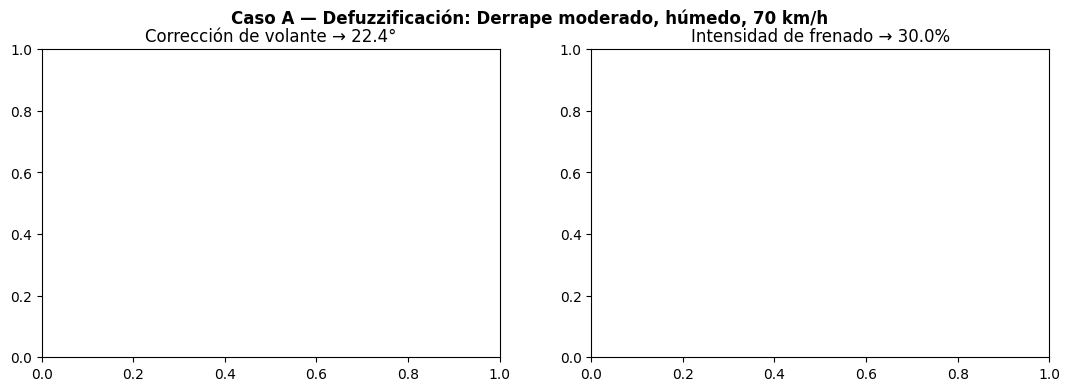

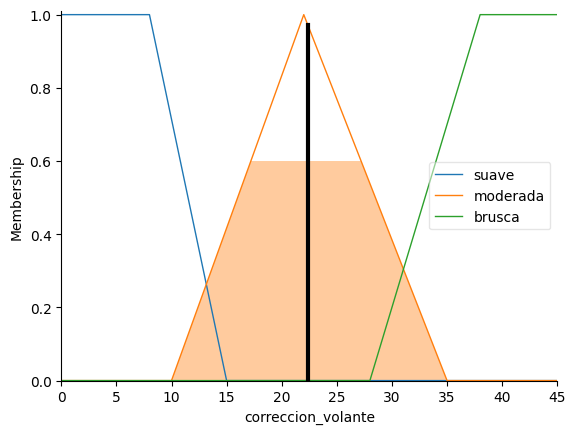

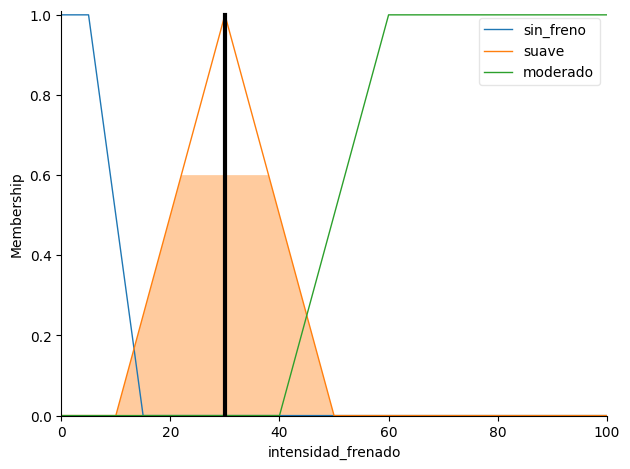

In [7]:
# Visualización de la defuzzificación para el escenario más representativo
# (Derrape moderado, húmedo, velocidad media)
sim_A.input['angulo_derrape']  = 20
sim_A.input['velocidad']       = 70
sim_A.input['humedad_calzada'] = 60
sim_A.compute()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Caso A — Defuzzificación: Derrape moderado, húmedo, 70 km/h', fontsize=12, fontweight='bold')
correccion.view(sim=sim_A, ax=axes[0])
axes[0].set_title(f'Corrección de volante → {sim_A.output["correccion_volante"]:.1f}°')
frenado.view(sim=sim_A, ax=axes[1])
axes[1].set_title(f'Intensidad de frenado → {sim_A.output["intensidad_frenado"]:.1f}%')
plt.tight_layout()
plt.show()

---
## CASO B — Vehículo de Tracción Trasera

### Universo del Discurso

En tracción trasera el motor empuja desde las ruedas traseras. Cuando se excede la adherencia trasera, la cola del vehículo se desplaza lateralmente. La acción **prioritaria** es reducir la potencia (soltar el acelerador), no frenar.

| Variable | Rango | Unidad | Rol |
|---|---|---|---|
| Ángulo de derrape | 0 – 45 | grados (°) | Antecedente |
| % de acelerador pisado | 0 – 100 | % | Antecedente |
| Humedad de la calzada | 0 – 100 | % | Antecedente |
| Corrección del volante | 0 – 45 | grados (°) | Consecuente |
| Reducción del acelerador | 0 – 100 | % | Consecuente |

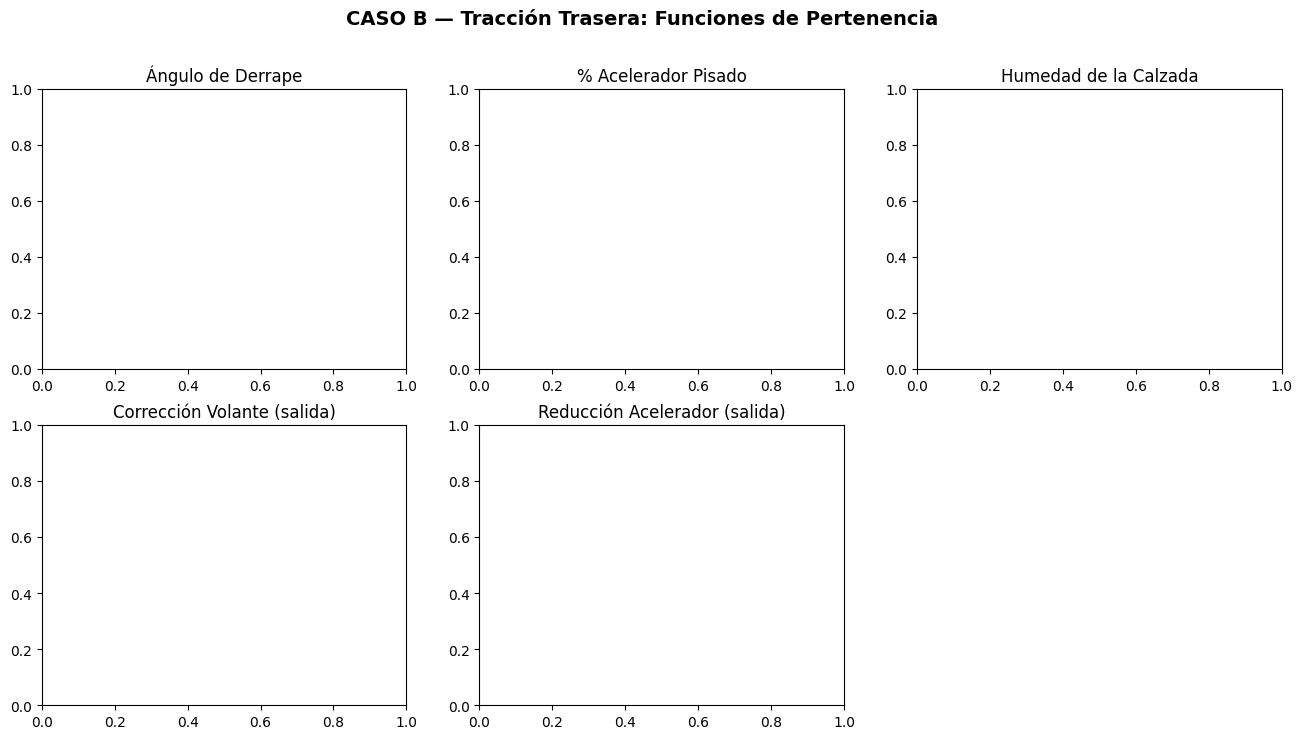

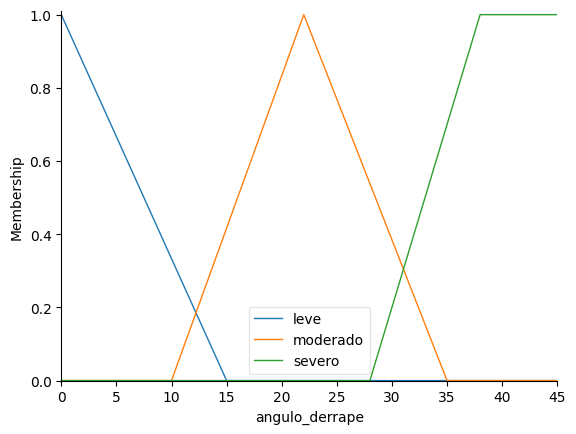

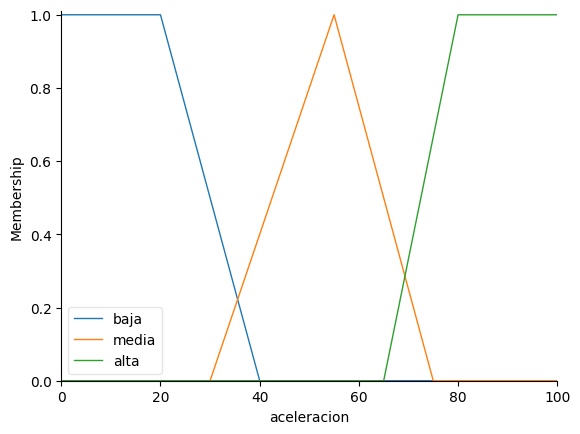

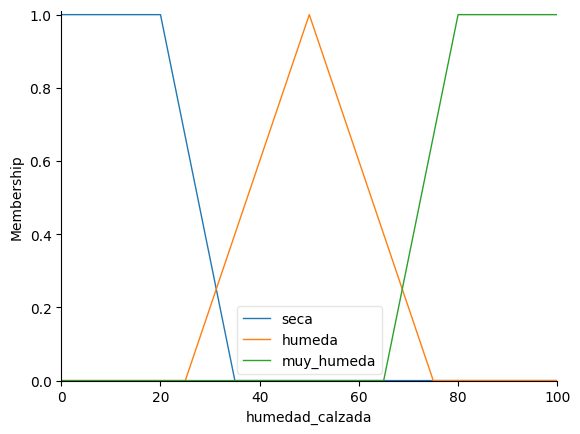

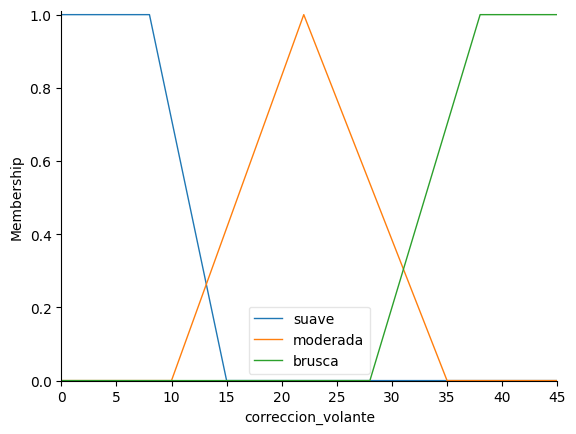

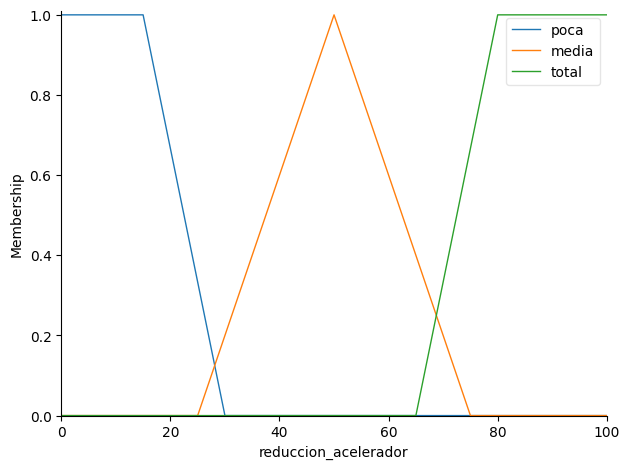

✓ Funciones de pertenencia Caso B definidas


In [8]:
# ============================================================
# CASO B: VEHÍCULO DE TRACCIÓN TRASERA
# ============================================================

# --- PASO 1 y 2: UNIVERSOS DE DISCURSO Y VARIABLES LINGÜÍSTICAS ---

# Antecedentes
angulo_B    = ctrl.Antecedent(np.arange(0, 46, 1),  'angulo_derrape')
aceleracion = ctrl.Antecedent(np.arange(0, 101, 1), 'aceleracion')      # % pedal pisado
humedad_B   = ctrl.Antecedent(np.arange(0, 101, 1), 'humedad_calzada')

# Consecuentes
# En TT la corrección de volante va en la MISMA dirección del derrape (contravolante)
correccion_B  = ctrl.Consequent(np.arange(0, 46, 1),  'correccion_volante')
# La reducción del acelerador es la acción PRINCIPAL en tracción trasera
reduccion_acc = ctrl.Consequent(np.arange(0, 101, 1), 'reduccion_acelerador')

# --- PASO 3: FUNCIONES DE PERTENENCIA ---

# Ángulo de derrape
angulo_B['leve']     = fuzz.trimf(angulo_B.universe,  [0, 0, 15])
angulo_B['moderado'] = fuzz.trimf(angulo_B.universe,  [10, 22, 35])
angulo_B['severo']   = fuzz.trapmf(angulo_B.universe, [28, 38, 45, 45])

# Porcentaje de acelerador
aceleracion['baja']  = fuzz.trapmf(aceleracion.universe, [0, 0, 20, 40])      # Pie casi suelto
aceleracion['media'] = fuzz.trimf(aceleracion.universe,  [30, 55, 75])        # Aceleración media
aceleracion['alta']  = fuzz.trapmf(aceleracion.universe, [65, 80, 100, 100])  # Fondo del pedal

# Humedad de la calzada
humedad_B['seca']       = fuzz.trapmf(humedad_B.universe, [0, 0, 20, 35])
humedad_B['humeda']     = fuzz.trimf(humedad_B.universe,  [25, 50, 75])
humedad_B['muy_humeda'] = fuzz.trapmf(humedad_B.universe, [65, 80, 100, 100])

# Corrección del volante
correccion_B['suave']    = fuzz.trapmf(correccion_B.universe, [0, 0, 8, 15])
correccion_B['moderada'] = fuzz.trimf(correccion_B.universe,  [10, 22, 35])
correccion_B['brusca']   = fuzz.trapmf(correccion_B.universe, [28, 38, 45, 45])

# Reducción del acelerador (consecuente principal en TT)
reduccion_acc['poca']  = fuzz.trapmf(reduccion_acc.universe, [0, 0, 15, 30])     # Apenas sueltas
reduccion_acc['media'] = fuzz.trimf(reduccion_acc.universe,  [25, 50, 75])       # Reducción parcial
reduccion_acc['total'] = fuzz.trapmf(reduccion_acc.universe, [65, 80, 100, 100]) # Pie completamente suelto

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('CASO B — Tracción Trasera: Funciones de Pertenencia',
             fontsize=14, fontweight='bold')
angulo_B.view(ax=axes[0, 0]);    axes[0, 0].set_title('Ángulo de Derrape')
aceleracion.view(ax=axes[0, 1]); axes[0, 1].set_title('% Acelerador Pisado')
humedad_B.view(ax=axes[0, 2]);   axes[0, 2].set_title('Humedad de la Calzada')
correccion_B.view(ax=axes[1, 0]); axes[1, 0].set_title('Corrección Volante (salida)')
reduccion_acc.view(ax=axes[1, 1]); axes[1, 1].set_title('Reducción Acelerador (salida)')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()
print('✓ Funciones de pertenencia Caso B definidas')

In [9]:
# --- PASO 4: REGLAS DIFUSAS — CASO B ---
# En TT la REDUCCIÓN DEL ACELERADOR es la acción principal.
# El motor que empuja las ruedas traseras CAUSA el derrape → hay que quitarle potencia.
# Frenar durante un derrape trasero activo es extremadamente peligroso.

reglas_B = [
    # --- Derrape LEVE ---
    ctrl.Rule(angulo_B['leve'] & aceleracion['baja'],
              (correccion_B['suave'], reduccion_acc['poca'])),      # Leve + poco gas → ajuste mínimo

    ctrl.Rule(angulo_B['leve'] & aceleracion['media'],
              (correccion_B['suave'], reduccion_acc['media'])),     # Leve + gas medio → reducir gas

    ctrl.Rule(angulo_B['leve'] & aceleracion['alta'],
              (correccion_B['moderada'], reduccion_acc['media'])),  # Leve + gas alto → más corrección

    # --- Derrape MODERADO ---
    ctrl.Rule(angulo_B['moderado'] & aceleracion['baja'],
              (correccion_B['moderada'], reduccion_acc['media'])),  # Moderado + poco gas → volante

    ctrl.Rule(angulo_B['moderado'] & aceleracion['alta'],
              (correccion_B['brusca'], reduccion_acc['total'])),    # Moderado + gas alto → SUELTA TODO

    ctrl.Rule(angulo_B['moderado'] & humedad_B['humeda'],
              (correccion_B['moderada'], reduccion_acc['media'])),  # Mojado moderado → reducción media

    ctrl.Rule(angulo_B['moderado'] & humedad_B['muy_humeda'],
              (correccion_B['brusca'], reduccion_acc['total'])),    # Mojado extremo → máxima reducción

    # --- Derrape SEVERO ---
    ctrl.Rule(angulo_B['severo'] & aceleracion['alta'],
              (correccion_B['brusca'], reduccion_acc['total'])),    # Severo + gas alto → emergencia total

    ctrl.Rule(angulo_B['severo'] & humedad_B['seca'],
              (correccion_B['brusca'], reduccion_acc['media'])),    # Severo en seco → algo de reducción

    ctrl.Rule(angulo_B['severo'] & humedad_B['humeda'],
              (correccion_B['brusca'], reduccion_acc['total'])),    # Severo húmedo → total reducción

    ctrl.Rule(angulo_B['severo'] & humedad_B['muy_humeda'],
              (correccion_B['brusca'], reduccion_acc['total'])),    # Situación más peligrosa: todo suave

    # --- Combinación crítica: gas alto + lluvia extrema ---
    ctrl.Rule(aceleracion['alta'] & humedad_B['muy_humeda'],
              (correccion_B['brusca'], reduccion_acc['total'])),    # Gas + lluvia: SUELTA EL ACELERADOR
]

# --- PASO 5: CONSTRUCCIÓN DEL SISTEMA ---
sistema_B = ctrl.ControlSystem(reglas_B)
sim_B     = ctrl.ControlSystemSimulation(sistema_B)

print(f'✓ Sistema de control difuso Caso B construido')
print(f'  Total de reglas definidas: {len(reglas_B)}')
print(f'  Antecedentes : angulo_derrape, aceleracion, humedad_calzada')
print(f'  Consecuentes : correccion_volante, reduccion_acelerador')

✓ Sistema de control difuso Caso B construido
  Total de reglas definidas: 12
  Antecedentes : angulo_derrape, aceleracion, humedad_calzada
  Consecuentes : correccion_volante, reduccion_acelerador


In [10]:
# --- PASO 6: SIMULACIÓN Y DEFUZZIFICACIÓN — CASO B ---

escenarios_B = [
    {'angulo': 8,  'aceleracion': 30, 'humedad': 20,
     'desc': 'Derrape leve, calzada seca, aceleración baja'},
    {'angulo': 22, 'aceleracion': 70, 'humedad': 55,
     'desc': 'Derrape moderado, húmedo, aceleración alta'},
    {'angulo': 38, 'aceleracion': 85, 'humedad': 90,
     'desc': 'Derrape severo, lluvia, aceleración alta'},
    {'angulo': 18, 'aceleracion': 60, 'humedad': 80,
     'desc': 'Derrape moderado en lluvia intensa'},
]

print('=' * 68)
print('        CASO B — TRACCIÓN TRASERA: Resultados de Simulación')
print('=' * 68)

for esc in escenarios_B:
    sim_B.input['angulo_derrape']      = esc['angulo']
    sim_B.input['aceleracion']         = esc['aceleracion']
    sim_B.input['humedad_calzada']     = esc['humedad']
    sim_B.compute()  # DEFUZZIFICACIÓN

    corr = sim_B.output['correccion_volante']
    red  = sim_B.output['reduccion_acelerador']

    icono = '🔴' if red > 70 else ('🟡' if red > 40 else '🟢')
    consejo = 'Suelta el acelerador completamente' if red > 70 else \
              ('Reduce el gas gradualmente' if red > 40 else 'Ajuste mínimo del gas')

    print(f'\n📍 {esc["desc"]}')
    print(f'   ENTRADAS → Ángulo: {esc["angulo"]:2d}°  |  Acelerador: {esc["aceleracion"]:3d}%  |  Humedad: {esc["humedad"]:3d}%')
    print(f'   SALIDAS  → Corrección volante: {corr:.1f}°  |  Reducción acelerador: {red:.1f}%')
    print(f'   CONSEJO  → {icono} {consejo}')

print('\n' + '=' * 68)

        CASO B — TRACCIÓN TRASERA: Resultados de Simulación

📍 Derrape leve, calzada seca, aceleración baja
   ENTRADAS → Ángulo:  8°  |  Acelerador:  30%  |  Humedad:  20%
   SALIDAS  → Corrección volante: 6.7°  |  Reducción acelerador: 13.3%
   CONSEJO  → 🟢 Ajuste mínimo del gas

📍 Derrape moderado, húmedo, aceleración alta
   ENTRADAS → Ángulo: 22°  |  Acelerador:  70%  |  Humedad:  55%
   SALIDAS  → Corrección volante: 26.5°  |  Reducción acelerador: 60.2%
   CONSEJO  → 🟡 Reduce el gas gradualmente

📍 Derrape severo, lluvia, aceleración alta
   ENTRADAS → Ángulo: 38°  |  Acelerador:  85%  |  Humedad:  90%
   SALIDAS  → Corrección volante: 38.7°  |  Reducción acelerador: 85.9%
   CONSEJO  → 🔴 Suelta el acelerador completamente

📍 Derrape moderado en lluvia intensa
   ENTRADAS → Ángulo: 18°  |  Acelerador:  60%  |  Humedad:  80%
   SALIDAS  → Corrección volante: 38.0°  |  Reducción acelerador: 84.9%
   CONSEJO  → 🔴 Suelta el acelerador completamente



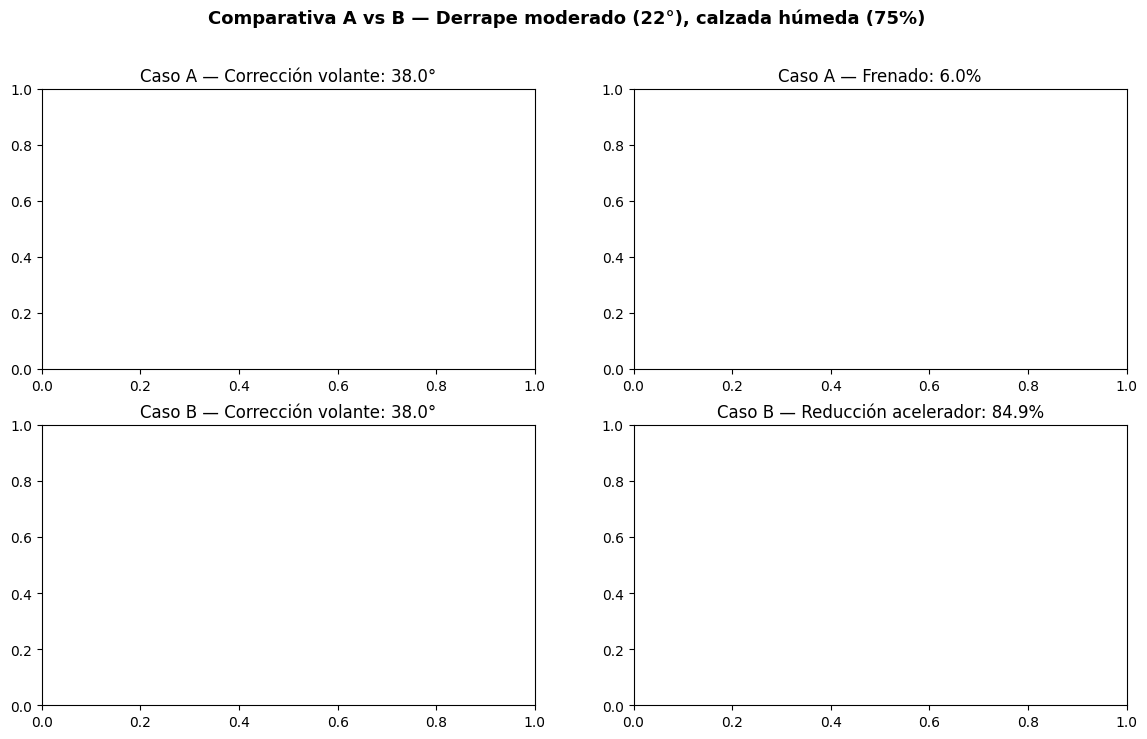

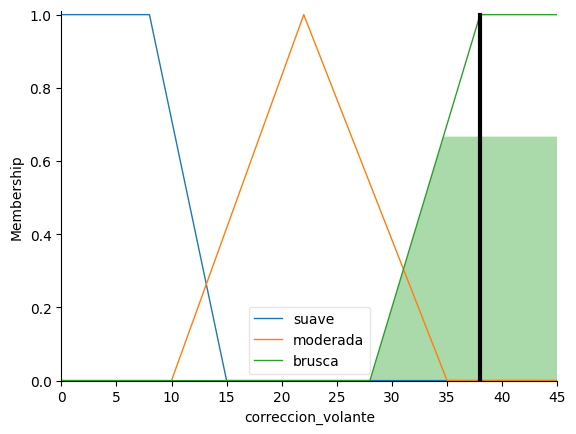

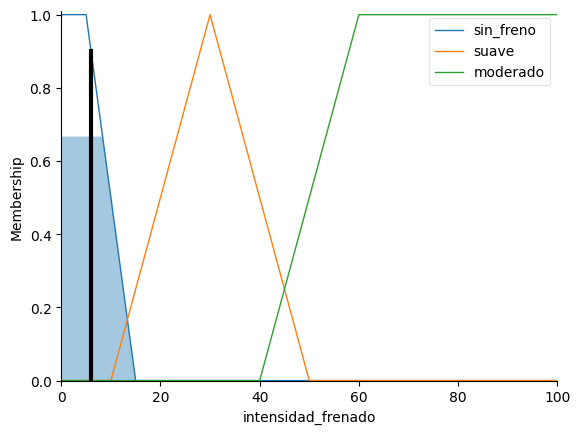

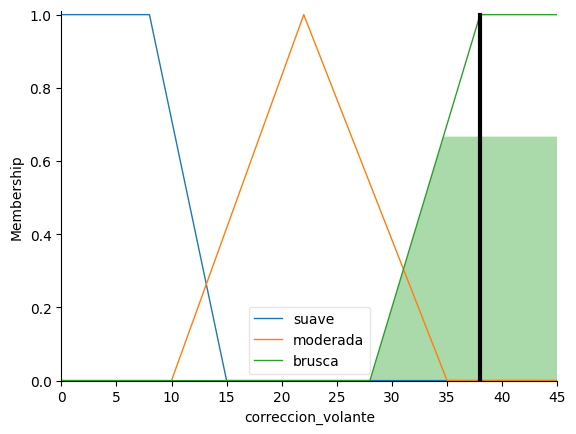

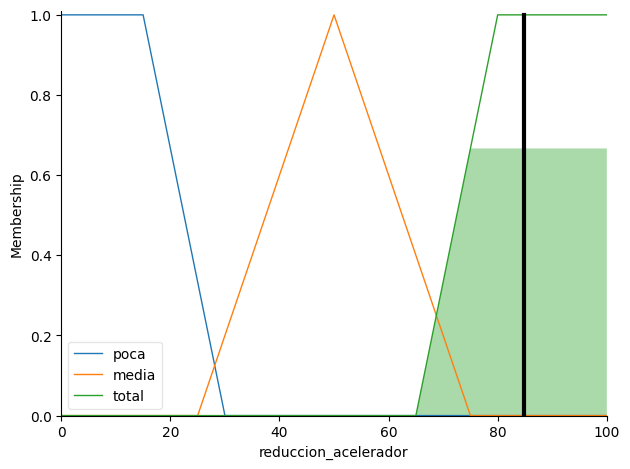

Interpretación:
  Caso A (TD): Frena 6% + Gira 38°
  Caso B (TT): Suelta acelerador 85% + Gira 38°
  → En TT la reducción del gas es mucho mayor que el frenado en TD


In [11]:
# Gráfico comparativo: mismo escenario en Caso A vs Caso B
# Escenario: derrape moderado (22°), calzada húmeda (75%)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Comparativa A vs B — Derrape moderado (22°), calzada húmeda (75%)',
             fontsize=13, fontweight='bold')

# Caso A con velocidad 65 km/h
sim_A.input['angulo_derrape']  = 22
sim_A.input['velocidad']       = 65
sim_A.input['humedad_calzada'] = 75
sim_A.compute()

correccion.view(sim=sim_A, ax=axes[0, 0])
axes[0, 0].set_title(f'Caso A — Corrección volante: {sim_A.output["correccion_volante"]:.1f}°')
frenado.view(sim=sim_A, ax=axes[0, 1])
axes[0, 1].set_title(f'Caso A — Frenado: {sim_A.output["intensidad_frenado"]:.1f}%')

# Caso B con aceleración 65%
sim_B.input['angulo_derrape']  = 22
sim_B.input['aceleracion']     = 65
sim_B.input['humedad_calzada'] = 75
sim_B.compute()

correccion_B.view(sim=sim_B, ax=axes[1, 0])
axes[1, 0].set_title(f'Caso B — Corrección volante: {sim_B.output["correccion_volante"]:.1f}°')
reduccion_acc.view(sim=sim_B, ax=axes[1, 1])
axes[1, 1].set_title(f'Caso B — Reducción acelerador: {sim_B.output["reduccion_acelerador"]:.1f}%')

plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  Caso A (TD): Frena {sim_A.output["intensidad_frenado"]:.0f}% + Gira {sim_A.output["correccion_volante"]:.0f}°')
print(f'  Caso B (TT): Suelta acelerador {sim_B.output["reduccion_acelerador"]:.0f}% + Gira {sim_B.output["correccion_volante"]:.0f}°')
print('  → En TT la reducción del gas es mucho mayor que el frenado en TD')

---
## Problema 2: Aplicación de Lógica Difusa en Entorno Laboral

### Sistema de Evaluación de Riesgo Crediticio — Sector Financiero/Bancario

**Contexto del problema:**  
En instituciones financieras, la evaluación crediticia no puede basarse en umbrales rígidos. Preguntas como *"¿qué ingreso es suficiente?"* o *"¿cuánta deuda es demasiada?"* son inherentemente **difusas**. Un sistema de lógica difusa permite modelar estas valoraciones de forma natural, tal como lo haría un analista de crédito experimentado.

### Universo del Discurso

| Variable | Rango | Unidad | Rol |
|---|---|---|---|
| Ingreso mensual neto | 0 – 10.000 | USD | Antecedente |
| Nivel de endeudamiento | 0 – 100 | % (deuda/ingreso) | Antecedente |
| Score de historial crediticio | 0 – 100 | puntos | Antecedente |
| Nivel de riesgo crediticio | 0 – 100 | índice | Consecuente |

### Variables Lingüísticas
- **Ingreso:** bajo / medio / alto
- **Endeudamiento:** bajo / medio / alto
- **Historial:** malo / regular / bueno
- **Riesgo (salida):** bajo / medio / alto

### Funciones de Pertenencia
Se usan formas **trapezoidales** para los extremos (rangos estables de "claramente bajo" o "claramente alto") y **triangulares** para los estados intermedios de transición.

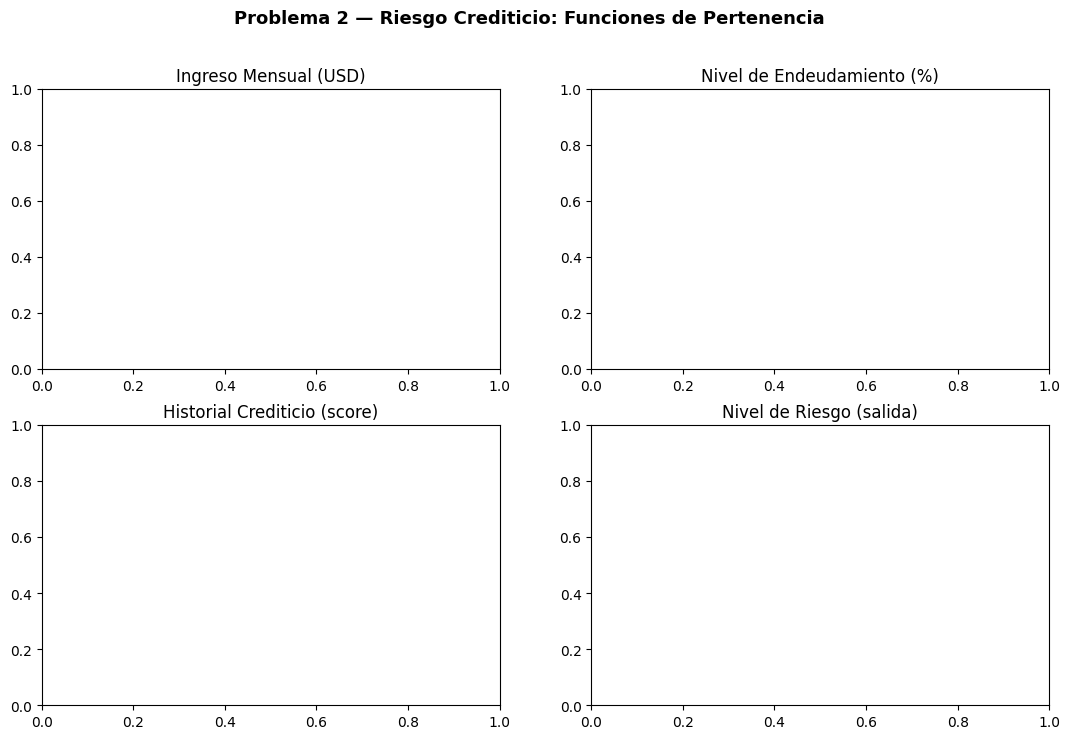

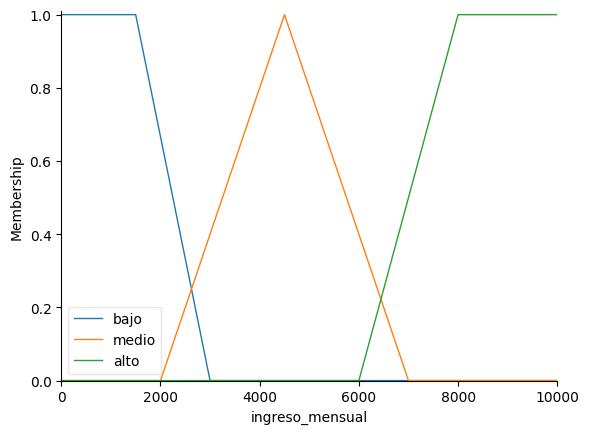

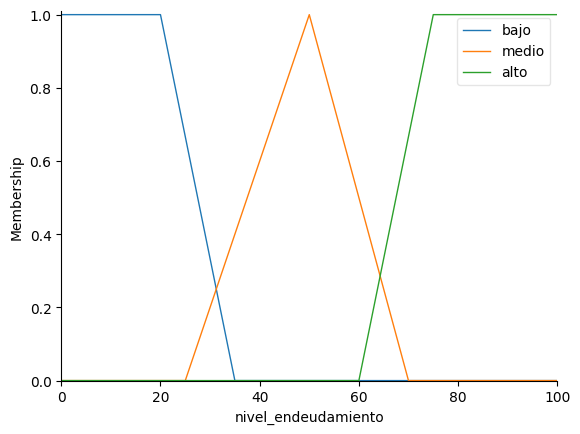

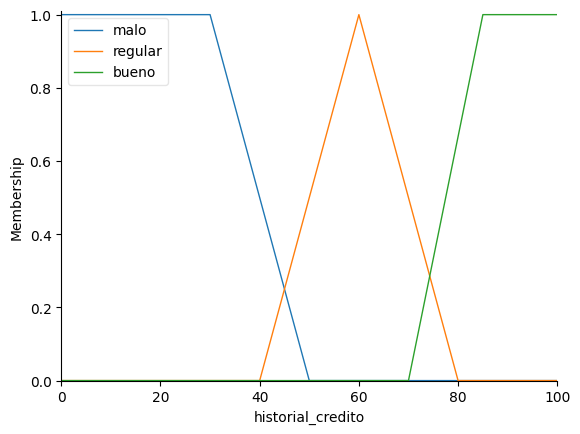

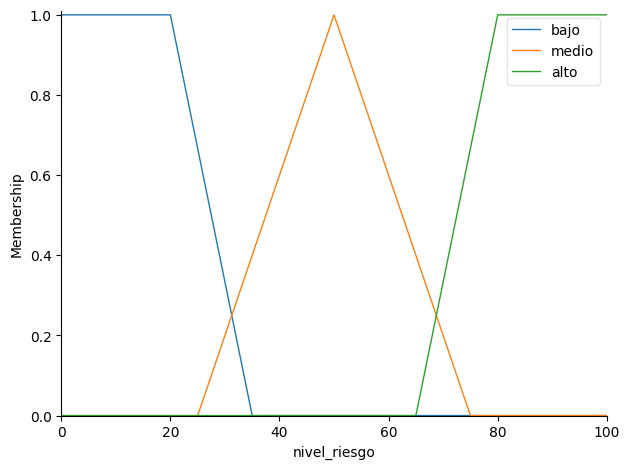

  PROBLEMA 2 — RIESGO CREDITICIO: Evaluación de Clientes

👤 Cliente A — Perfil ideal
   Ingreso: $7,500  |  Endeudamiento: 18%  |  Score: 90
   Riesgo calculado: 14.9/100  →  ✅ APROBADO

👤 Cliente B — Perfil medio
   Ingreso: $3,500  |  Endeudamiento: 52%  |  Score: 65
   Riesgo calculado: 50.0/100  →  ⚠️  CONDICIONAL

👤 Cliente C — Alto riesgo
   Ingreso: $1,100  |  Endeudamiento: 82%  |  Score: 22
   Riesgo calculado: 85.9/100  →  ❌ RECHAZADO

👤 Cliente D — Perfil aceptable
   Ingreso: $5,000  |  Endeudamiento: 30%  |  Score: 75
   Riesgo calculado: 31.7/100  →  ✅ APROBADO



In [12]:
# ============================================================
# PROBLEMA 2: EVALUACIÓN DE RIESGO CREDITICIO
# ============================================================

# Universos de discurso
ingreso       = ctrl.Antecedent(np.arange(0, 10001, 100), 'ingreso_mensual')
endeudamiento = ctrl.Antecedent(np.arange(0, 101, 1),     'nivel_endeudamiento')
historial     = ctrl.Antecedent(np.arange(0, 101, 1),     'historial_credito')
riesgo        = ctrl.Consequent(np.arange(0, 101, 1),     'nivel_riesgo')

# Funciones de pertenencia — Antecedentes
ingreso['bajo']  = fuzz.trapmf(ingreso.universe, [0, 0, 1500, 3000])          # < $3000
ingreso['medio'] = fuzz.trimf(ingreso.universe,  [2000, 4500, 7000])           # $2000–$7000
ingreso['alto']  = fuzz.trapmf(ingreso.universe, [6000, 8000, 10000, 10000])  # > $6000

endeudamiento['bajo']  = fuzz.trapmf(endeudamiento.universe, [0, 0, 20, 35])      # < 35%
endeudamiento['medio'] = fuzz.trimf(endeudamiento.universe,  [25, 50, 70])        # 25–70%
endeudamiento['alto']  = fuzz.trapmf(endeudamiento.universe, [60, 75, 100, 100]) # > 60%

historial['malo']    = fuzz.trapmf(historial.universe, [0, 0, 30, 50])     # Score < 50
historial['regular'] = fuzz.trimf(historial.universe,  [40, 60, 80])       # Score 40–80
historial['bueno']   = fuzz.trapmf(historial.universe, [70, 85, 100, 100]) # Score > 70

# Funciones de pertenencia — Consecuente
riesgo['bajo']  = fuzz.trapmf(riesgo.universe, [0, 0, 20, 35])
riesgo['medio'] = fuzz.trimf(riesgo.universe,  [25, 50, 75])
riesgo['alto']  = fuzz.trapmf(riesgo.universe, [65, 80, 100, 100])

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Problema 2 — Riesgo Crediticio: Funciones de Pertenencia', fontsize=13, fontweight='bold')
ingreso.view(ax=axes[0, 0]);       axes[0, 0].set_title('Ingreso Mensual (USD)')
endeudamiento.view(ax=axes[0, 1]); axes[0, 1].set_title('Nivel de Endeudamiento (%)')
historial.view(ax=axes[1, 0]);     axes[1, 0].set_title('Historial Crediticio (score)')
riesgo.view(ax=axes[1, 1]);        axes[1, 1].set_title('Nivel de Riesgo (salida)')
plt.tight_layout()
plt.show()

# Reglas difusas
reglas_credito = [
    ctrl.Rule(ingreso['alto']  & endeudamiento['bajo']  & historial['bueno'],   riesgo['bajo']),
    ctrl.Rule(ingreso['medio'] & endeudamiento['bajo']  & historial['bueno'],   riesgo['bajo']),
    ctrl.Rule(ingreso['alto']  & endeudamiento['medio'] & historial['bueno'],   riesgo['bajo']),
    ctrl.Rule(ingreso['medio'] & endeudamiento['medio'] & historial['regular'], riesgo['medio']),
    ctrl.Rule(ingreso['alto']  & endeudamiento['alto']  & historial['regular'], riesgo['medio']),
    ctrl.Rule(ingreso['bajo']  & endeudamiento['bajo']  & historial['bueno'],   riesgo['medio']),
    ctrl.Rule(ingreso['bajo']  & endeudamiento['medio'],                         riesgo['alto']),
    ctrl.Rule(ingreso['bajo']  & endeudamiento['alto'],                          riesgo['alto']),
    ctrl.Rule(historial['malo'],                                                  riesgo['alto']),
    ctrl.Rule(ingreso['medio'] & endeudamiento['alto']  & historial['malo'],    riesgo['alto']),
]

sistema_credito = ctrl.ControlSystem(reglas_credito)
sim_credito     = ctrl.ControlSystemSimulation(sistema_credito)

# Simulación con perfiles de clientes reales
clientes = [
    {'ingreso': 7500, 'deuda': 18, 'score': 90, 'nombre': 'Cliente A — Perfil ideal'},
    {'ingreso': 3500, 'deuda': 52, 'score': 65, 'nombre': 'Cliente B — Perfil medio'},
    {'ingreso': 1100, 'deuda': 82, 'score': 22, 'nombre': 'Cliente C — Alto riesgo'},
    {'ingreso': 5000, 'deuda': 30, 'score': 75, 'nombre': 'Cliente D — Perfil aceptable'},
]

print('=' * 65)
print('  PROBLEMA 2 — RIESGO CREDITICIO: Evaluación de Clientes')
print('=' * 65)

for c in clientes:
    sim_credito.input['ingreso_mensual']     = c['ingreso']
    sim_credito.input['nivel_endeudamiento'] = c['deuda']
    sim_credito.input['historial_credito']   = c['score']
    sim_credito.compute()
    r = sim_credito.output['nivel_riesgo']
    decision = '✅ APROBADO'     if r < 35 else \
               '⚠️  CONDICIONAL' if r < 65 else \
               '❌ RECHAZADO'
    print(f'\n👤 {c["nombre"]}')
    print(f'   Ingreso: ${c["ingreso"]:,}  |  Endeudamiento: {c["deuda"]}%  |  Score: {c["score"]}')
    print(f'   Riesgo calculado: {r:.1f}/100  →  {decision}')

print('\n' + '=' * 65)

---
# PARTE 2 — Algoritmo PSO: Formación de Drones (50%)

## Descripción del Problema

Se implementa el algoritmo **PSO (Particle Swarm Optimization)** para optimizar las posiciones de una flota de **6 drones** manteniendo formaciones geométricas dentro de un área de vuelo de 100×100 metros.

### Conceptos clave
- **Partícula:** una configuración completa de posiciones de los 6 drones (vector de 12 valores: 6×(x,y))
- **Fitness:** medida de qué tan bien se mantiene la formación (se minimiza)
- **pBest:** mejor posición que esa partícula ha encontrado
- **gBest:** mejor posición encontrada por cualquier partícula del enjambre

### Pseudocódigo PSO (del enunciado)
```
Asignar posiciones y velocidades aleatorias iniciales a las partículas
Repetir
   Cada partícula:
      Actualizar su velocidad considerando:
         Inercia de la partícula (la hace seguir con la misma velocidad)
         Atracción al mejor personal
         Atracción al mejor global
      Actualizar la posición de la partícula
      Calcular el valor de fitness en la nueva posición
      Actualizar su mejor personal
      Actualizar el mejor global del sistema
Devolver el mejor global
```

In [13]:
# ============================================================
# PARÁMETROS DEL PROBLEMA Y DEL ALGORITMO PSO
# (variables que estaban vacías en el código base del enunciado)
# ============================================================

# --- Parámetros del problema ---
NUM_DRONES           = 6       # Número de drones en la flota
DIMENSIONS           = 2       # Espacio de vuelo 2D (coordenadas x, y)
AREA_WIDTH           = 100     # Ancho del área de vuelo en metros
AREA_HEIGHT          = 100     # Alto del área de vuelo en metros
MIN_SAFE_DISTANCE    = 5.0     # Distancia mínima de seguridad entre drones (metros)
FORMATION_DISTANCE_L = 15.0    # Distancia entre drones consecutivos en la formación (metros)

# --- Parámetros del algoritmo PSO ---
NUM_PARTICLES  = 80     # Número de partículas: más partículas = mejor exploración, más tiempo
MAX_ITERATIONS = 200    # Iteraciones máximas del algoritmo

# Coeficientes PSO
W   = 0.5    # Inercia: controla qué tanto sigue la partícula su trayectoria previa
             # W alto → más exploración; W bajo → más explotación
C1  = 1.5    # Coeficiente cognitivo: atracción hacia el mejor personal (pBest)
C2  = 1.5    # Coeficiente social: atracción hacia el mejor global (gBest)
V_MAX = 10.0  # Velocidad máxima permitida por iteración (metros)

print('✓ Parámetros configurados:')
print(f'  Drones        : {NUM_DRONES}')
print(f'  Área de vuelo : {AREA_WIDTH} x {AREA_HEIGHT} metros')
print(f'  Dist. mínima  : {MIN_SAFE_DISTANCE} m entre drones')
print(f'  Dist. formación: {FORMATION_DISTANCE_L} m')
print(f'  Partículas    : {NUM_PARTICLES}')
print(f'  Iteraciones   : {MAX_ITERATIONS}')
print(f'  W={W}  C1={C1}  C2={C2}  V_max={V_MAX}')

✓ Parámetros configurados:
  Drones        : 6
  Área de vuelo : 100 x 100 metros
  Dist. mínima  : 5.0 m entre drones
  Dist. formación: 15.0 m
  Partículas    : 80
  Iteraciones   : 200
  W=0.5  C1=1.5  C2=1.5  V_max=10.0


✓ Formación "line" → 6 drones
✓ Formación "triangle" → 6 drones
✓ Formación "H" → 6 drones
✓ Formación "rectangle" → 6 drones


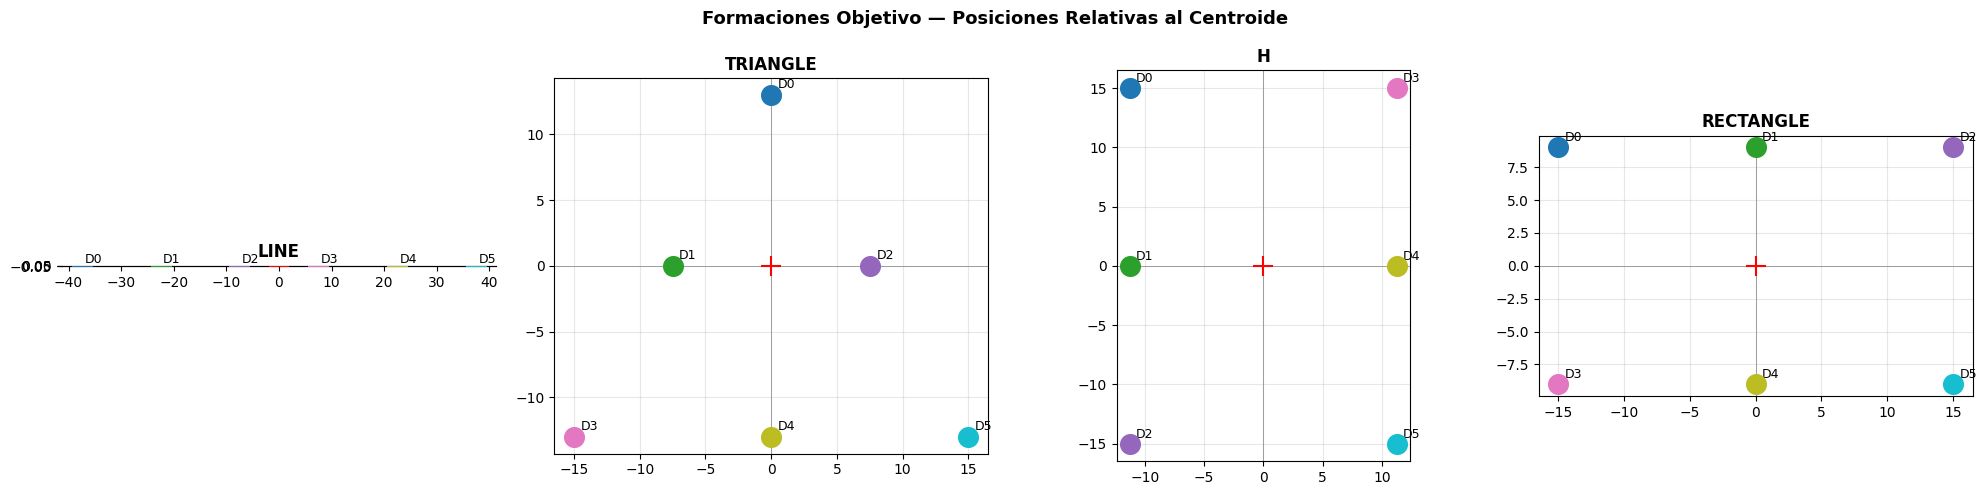

In [14]:
# ============================================================
# FORMACIONES OBJETIVO
# Retorna posiciones relativas de cada dron respecto al centroide
# El algoritmo puede ubicar la formación en cualquier punto del área
# ============================================================

def get_target_formation_relative_positions(formation_type="line"):
    """
    Calcula las posiciones relativas ideales de los drones
    respecto al centroide de la formación.

    Soporta:
    - 'line'     : Línea horizontal de 6 drones
    - 'triangle' : Formación triangular de 6 drones (dos niveles)
    - 'H'        : Formación en H (dos columnas + barra central)
    - 'rectangle': Formación rectangular (2 filas de 3)
    """
    targets = np.zeros((NUM_DRONES, DIMENSIONS))
    L = FORMATION_DISTANCE_L

    if formation_type == "line":
        # Todos en fila horizontal centrada en el origen
        start_x = -(NUM_DRONES - 1) * L / 2.0
        for i in range(NUM_DRONES):
            targets[i, 0] = start_x + i * L   # Coordenada X
            targets[i, 1] = 0                  # Todos en Y=0

    elif formation_type == "triangle":
        # Triángulo de 6 drones: 1 en cima, 2 en fila media, 3 en base
        # Formación piramidal
        h = (np.sqrt(3) / 2) * L              # Altura de triángulo equilátero
        targets[0] = [0,        h]             # Cima (D0)
        targets[1] = [-L / 2,   0]             # Fila media izquierda (D1)
        targets[2] = [ L / 2,   0]             # Fila media derecha (D2)
        targets[3] = [-L,      -h]             # Base izquierda (D3)
        targets[4] = [ 0,      -h]             # Base centro (D4)
        targets[5] = [ L,      -h]             # Base derecha (D5)

    elif formation_type == "H":
        # Dos columnas verticales de 3 drones unidas por la barra central
        # D0, D1, D2 = columna izquierda | D3, D4, D5 = columna derecha
        # D1 y D4 forman la barra horizontal de la H
        col_sep = L * 1.5   # Separación horizontal entre columnas
        row_sep = L          # Separación vertical entre filas de cada columna

        # Columna izquierda
        targets[0] = [-col_sep / 2,  row_sep]  # Superior izquierdo
        targets[1] = [-col_sep / 2,  0       ] # Medio izquierdo (extremo barra H)
        targets[2] = [-col_sep / 2, -row_sep ] # Inferior izquierdo

        # Columna derecha
        targets[3] = [ col_sep / 2,  row_sep]  # Superior derecho
        targets[4] = [ col_sep / 2,  0      ]  # Medio derecho (extremo barra H)
        targets[5] = [ col_sep / 2, -row_sep]  # Inferior derecho

    elif formation_type == "rectangle":
        # Dos filas paralelas de 3 drones (rectángulo 3x2)
        half_n  = NUM_DRONES // 2              # = 3 drones por fila
        width   = (half_n - 1) * L             # Ancho del rectángulo
        height  = L * 1.2                      # Alto del rectángulo

        for i in range(half_n):
            x = -width / 2 + i * L
            targets[i]          = [x,  height / 2]  # Fila superior (D0,D1,D2)
            targets[i + half_n] = [x, -height / 2]  # Fila inferior (D3,D4,D5)
    else:
        raise ValueError(f"Formación '{formation_type}' no soportada.")

    return targets

# Verificar y visualizar las 4 formaciones
formaciones_nombres = ['line', 'triangle', 'H', 'rectangle']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Formaciones Objetivo — Posiciones Relativas al Centroide', fontsize=13, fontweight='bold')

colores = plt.cm.tab10(np.linspace(0, 1, NUM_DRONES))

for ax, fname in zip(axes, formaciones_nombres):
    pos = get_target_formation_relative_positions(fname)
    for i in range(NUM_DRONES):
        ax.scatter(*pos[i], s=200, color=colores[i], zorder=5)
        ax.text(pos[i, 0] + 0.5, pos[i, 1] + 0.5, f'D{i}', fontsize=9)
    ax.scatter(0, 0, marker='+', s=200, color='red', zorder=6, label='Centroide')
    ax.set_title(fname.upper(), fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    print(f'✓ Formación "{fname}" → {NUM_DRONES} drones')

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# FUNCIÓN DE FITNESS
# Evalúa la calidad de una configuración de drones.
# El algoritmo PSO MINIMIZA este valor.
# fitness = 0 → formación perfecta, sin colisiones, dentro del área
# ============================================================

def fitness_function(particle_position, target_relative_pos):
    """
    Calcula el costo total de una configuración de drones.

    Componentes:
      1. e_form    : Error de formación (distancia cuadrática a posición ideal)
      2. p_coll    : Penalización por colisión entre drones
      3. p_boundary: Penalización por salir del área de vuelo

    Parámetros:
      particle_position   (array 1D): posiciones de todos los drones concatenadas
      target_relative_pos (array 2D): posiciones ideales relativas al centroide

    Retorna:
      total_fitness (float): valor a minimizar
    """
    # Reshape: de vector 1D a matriz (NUM_DRONES x DIMENSIONS)
    drone_positions = particle_position.reshape((NUM_DRONES, DIMENSIONS))

    # 1. ERROR DE FORMACIÓN (e_form)
    # Se mide respecto al centroide ACTUAL del grupo,
    # lo que hace que la formación sea invariante a la posición absoluta.
    current_centroid = np.mean(drone_positions, axis=0)
    e_form = 0.0
    for i in range(NUM_DRONES):
        # Posición ideal del dron i = centroide actual + offset relativo ideal
        ideal_pos_i = current_centroid + target_relative_pos[i, :]
        # Error cuadrático entre posición real e ideal
        e_form += np.sum((drone_positions[i, :] - ideal_pos_i) ** 2)

    # 2. PENALIZACIÓN POR COLISIÓN (p_coll)
    # Si dos drones están más cerca que MIN_SAFE_DISTANCE se penaliza fuertemente.
    # El valor alto (10000) hace que el algoritmo aprenda a evitar colisiones.
    p_coll = 0.0
    collision_penalty_value = 10000  # Penalización fija y alta por cada colisión
    for i in range(NUM_DRONES):
        for j in range(i + 1, NUM_DRONES):  # Solo pares únicos (i,j) con i<j
            dist = np.sqrt(np.sum((drone_positions[i, :] - drone_positions[j, :]) ** 2))
            if dist < MIN_SAFE_DISTANCE:
                p_coll += collision_penalty_value  # Penalización fija por colisión

    # 3. PENALIZACIÓN POR LÍMITES DEL ÁREA DE VUELO (p_boundary)
    # Si un dron sale del área 100x100 metros, se penaliza.
    p_boundary = 0.0
    boundary_penalty_value = 1000
    for i in range(NUM_DRONES):
        if not (0 <= drone_positions[i, 0] <= AREA_WIDTH and
                0 <= drone_positions[i, 1] <= AREA_HEIGHT):
            p_boundary += boundary_penalty_value

    # PESOS de cada componente (justificación):
    # w1=1.0: el error de formación es el objetivo principal
    # w2=1.0: las colisiones son igualmente críticas (seguridad)
    # w3=0.5: los límites son importantes pero el clipping ya los controla
    w1 = 1.0   # Peso del error de formación
    w2 = 1.0   # Peso de la penalización por colisión
    w3 = 0.5   # Peso de la penalización por límites

    total_fitness = w1 * e_form + w2 * p_coll + w3 * p_boundary
    return total_fitness

print('✓ Función de fitness definida')
print('  Componentes: error_formación (w=1.0) + colisiones (w=1.0) + límites (w=0.5)')

✓ Función de fitness definida
  Componentes: error_formación (w=1.0) + colisiones (w=1.0) + límites (w=0.5)


In [16]:
# ============================================================
# IMPLEMENTACIÓN DEL ALGORITMO PSO
# ============================================================

def run_pso(formation_type, seed=42):
    """
    Ejecuta PSO para optimizar la formación de drones indicada.

    Implementa el pseudocódigo del enunciado:
    1. Inicializar posiciones y velocidades aleatorias
    2. Evaluar fitness → actualizar pBest y gBest
    3. Actualizar velocidad: v = W*v + C1*r1*(pBest-x) + C2*r2*(gBest-x)
    4. Actualizar posición: x = x + v
    5. Aplicar límites (clipping)
    6. Repetir hasta MAX_ITERATIONS
    7. Devolver el mejor global (gBest)

    Retorna:
      final_positions (array): posiciones finales de los 6 drones
      fitness_history (list) : historial de gBest por iteración
      target_rel_pos  (array): posiciones relativas objetivo
    """
    np.random.seed(seed)  # Reproducibilidad
    print(f'\n🚁 PSO — Formación: {formation_type.upper()} | '
          f'{NUM_PARTICLES} partículas | {MAX_ITERATIONS} iteraciones')
    print('-' * 60)

    # Obtener posiciones relativas objetivo
    target_rel_pos = get_target_formation_relative_positions(formation_type)

    # --- INICIALIZACIÓN ---
    # Cada partícula = vector de posiciones de todos los drones (NUM_DRONES*DIMENSIONS)
    particles_pos = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS)
    particles_pos[:, ::2]  *= AREA_WIDTH    # Coordenadas X dentro del área
    particles_pos[:, 1::2] *= AREA_HEIGHT   # Coordenadas Y dentro del área

    # Velocidades iniciales pequeñas (10% de V_MAX)
    particles_vel = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS) * V_MAX * 0.1

    # Mejor posición personal de cada partícula (pBest)
    pbest_pos     = np.copy(particles_pos)
    pbest_fitness = np.full(NUM_PARTICLES, float('inf'))

    # Mejor posición global del enjambre (gBest)
    gbest_pos     = np.zeros(NUM_DRONES * DIMENSIONS)
    gbest_fitness = float('inf')

    fitness_history = []  # Para graficar la convergencia

    # --- BUCLE PRINCIPAL PSO ---
    for iter_num in range(MAX_ITERATIONS):

        # Evaluar fitness de cada partícula y actualizar pBest / gBest
        for i in range(NUM_PARTICLES):
            current_fitness = fitness_function(particles_pos[i], target_rel_pos)

            # Actualizar mejor personal (pBest)
            if current_fitness < pbest_fitness[i]:
                pbest_fitness[i] = current_fitness
                pbest_pos[i]     = np.copy(particles_pos[i])

            # Actualizar mejor global (gBest)
            if current_fitness < gbest_fitness:
                gbest_fitness = current_fitness
                gbest_pos     = np.copy(particles_pos[i])

        # Guardar el mejor global de esta iteración
        fitness_history.append(gbest_fitness)

        # Actualizar velocidades y posiciones de todas las partículas
        for i in range(NUM_PARTICLES):
            # Números aleatorios para exploración estocástica
            r1 = np.random.rand(NUM_DRONES * DIMENSIONS)  # Componente cognitiva
            r2 = np.random.rand(NUM_DRONES * DIMENSIONS)  # Componente social

            # Componente cognitiva: atracción hacia el mejor personal
            cognitive_vel = C1 * r1 * (pbest_pos[i] - particles_pos[i])

            # Componente social: atracción hacia el mejor global
            social_vel = C2 * r2 * (gbest_pos - particles_pos[i])

            # FÓRMULA DE ACTUALIZACIÓN DE VELOCIDAD (PSO)
            # v(t+1) = W*v(t) + C1*r1*(pBest-x) + C2*r2*(gBest-x)
            particles_vel[i] = W * particles_vel[i] + cognitive_vel + social_vel

            # Limitar velocidad máxima para evitar divergencia
            particles_vel[i] = np.clip(particles_vel[i], -V_MAX, V_MAX)

            # Actualizar posición: x(t+1) = x(t) + v(t+1)
            particles_pos[i] += particles_vel[i]

            # Aplicar límites del área de vuelo (clipping)
            particles_pos[i, ::2]  = np.clip(particles_pos[i, ::2],  0, AREA_WIDTH)
            particles_pos[i, 1::2] = np.clip(particles_pos[i, 1::2], 0, AREA_HEIGHT)

        # Reportar progreso cada 50 iteraciones
        if (iter_num + 1) % 50 == 0:
            print(f'  Iteración {iter_num+1:3d}/{MAX_ITERATIONS} → gBest fitness: {gbest_fitness:.2f}')

    # Resultado final
    final_positions = gbest_pos.reshape((NUM_DRONES, DIMENSIONS))

    # Verificar colisiones en la solución final
    colisiones = sum(
        1 for i in range(NUM_DRONES) for j in range(i+1, NUM_DRONES)
        if np.linalg.norm(final_positions[i] - final_positions[j]) < MIN_SAFE_DISTANCE
    )

    print(f'\n  ✅ Fitness final    : {gbest_fitness:.4f}')
    print(f'  🛡️  Colisiones finales: {colisiones} (objetivo: 0)')

    return final_positions, fitness_history, target_rel_pos


def visualize_formation(final_positions, fitness_history, target_rel_pos, formation_type):
    """Genera gráficos de convergencia y formación final."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'PSO — Formación {formation_type.upper()} | {NUM_DRONES} drones',
                 fontsize=14, fontweight='bold')

    # Gráfico 1: Curva de convergencia del fitness
    ax1.plot(fitness_history, color='royalblue', linewidth=2)
    ax1.set_title('Convergencia del Fitness (gBest)')
    ax1.set_xlabel('Iteración')
    ax1.set_ylabel('Mejor Fitness Global (gBest)')
    ax1.grid(True, alpha=0.4)
    if min(fitness_history) > 0:
        ax1.set_yscale('log')
    ax1.annotate(f'Fitness final:\n{fitness_history[-1]:.2f}',
                 xy=(len(fitness_history)-1, fitness_history[-1]),
                 xytext=(-100, 30), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')

    # Gráfico 2: Posición final de los drones
    ax2.set_xlim(0, AREA_WIDTH)
    ax2.set_ylim(0, AREA_HEIGHT)
    ax2.set_aspect('equal')
    ax2.set_title(f'Formación Final | Fitness: {fitness_history[-1]:.2f}')
    ax2.set_xlabel('Coordenada X (metros)')
    ax2.set_ylabel('Coordenada Y (metros)')
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor('#f8f9fa')

    centroid  = np.mean(final_positions, axis=0)
    ideal_pos = centroid + target_rel_pos

    # Posiciones ideales (círculos vacíos grises)
    ax2.scatter(ideal_pos[:, 0], ideal_pos[:, 1], s=220, facecolors='none',
                edgecolors='gray', linewidths=2, zorder=4, label='Posición ideal')

    # Centroide actual
    ax2.scatter(*centroid, color='green', marker='*', s=250, zorder=7, label='Centroide')

    # Drones reales con círculo de seguridad
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_DRONES))
    for i in range(NUM_DRONES):
        ax2.scatter(*final_positions[i], s=180, color=colors[i], zorder=6)
        ax2.text(final_positions[i, 0]+1.5, final_positions[i, 1]+1.5, f'D{i}', fontsize=9)
        circle = plt.Circle(final_positions[i], MIN_SAFE_DISTANCE,
                             color=colors[i], fill=False, linestyle='--', alpha=0.5)
        ax2.add_artist(circle)

    ax2.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

print('✓ Funciones PSO y visualización definidas')

✓ Funciones PSO y visualización definidas



🚁 PSO — Formación: LINE | 80 partículas | 200 iteraciones
------------------------------------------------------------
  Iteración  50/200 → gBest fitness: 0.00
  Iteración 100/200 → gBest fitness: 0.00
  Iteración 150/200 → gBest fitness: 0.00
  Iteración 200/200 → gBest fitness: 0.00

  ✅ Fitness final    : 0.0000
  🛡️  Colisiones finales: 0 (objetivo: 0)


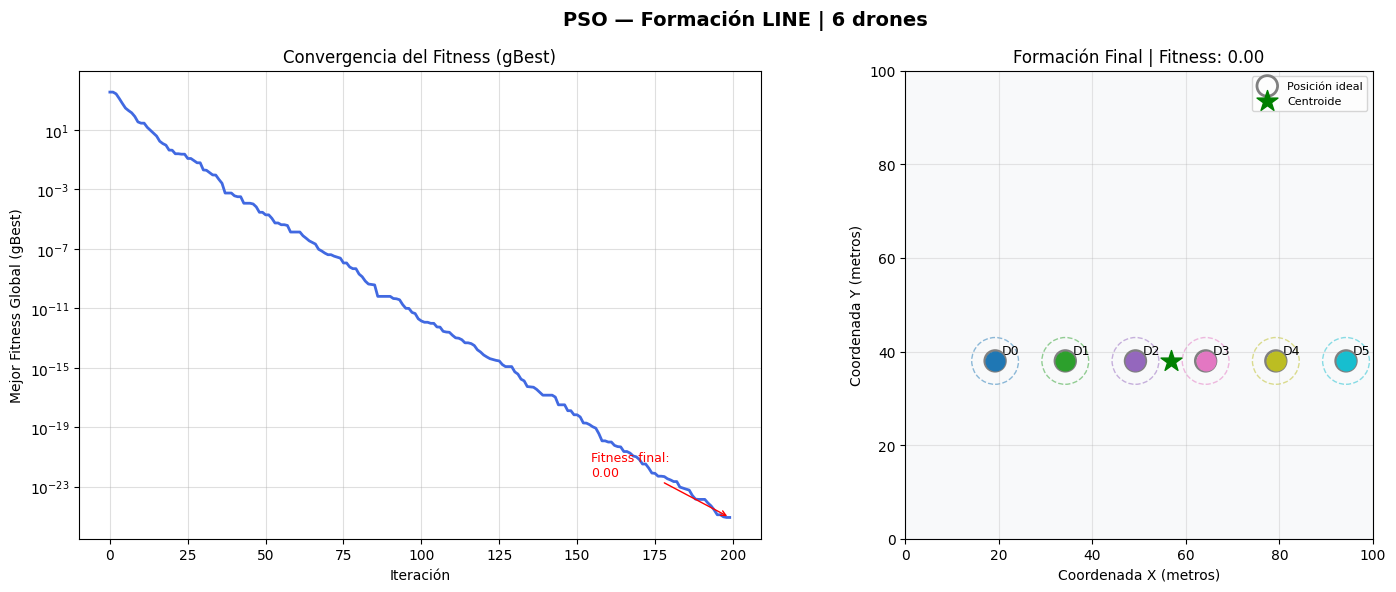

In [17]:
# ============================================================
# EJECUCIÓN 1: FORMACIÓN EN LÍNEA (del código base del enunciado)
# ============================================================
pos_line, hist_line, tgt_line = run_pso('line')
visualize_formation(pos_line, hist_line, tgt_line, 'line')


🚁 PSO — Formación: TRIANGLE | 80 partículas | 200 iteraciones
------------------------------------------------------------
  Iteración  50/200 → gBest fitness: 112.50
  Iteración 100/200 → gBest fitness: 112.50
  Iteración 150/200 → gBest fitness: 112.50
  Iteración 200/200 → gBest fitness: 112.50

  ✅ Fitness final    : 112.5000
  🛡️  Colisiones finales: 0 (objetivo: 0)


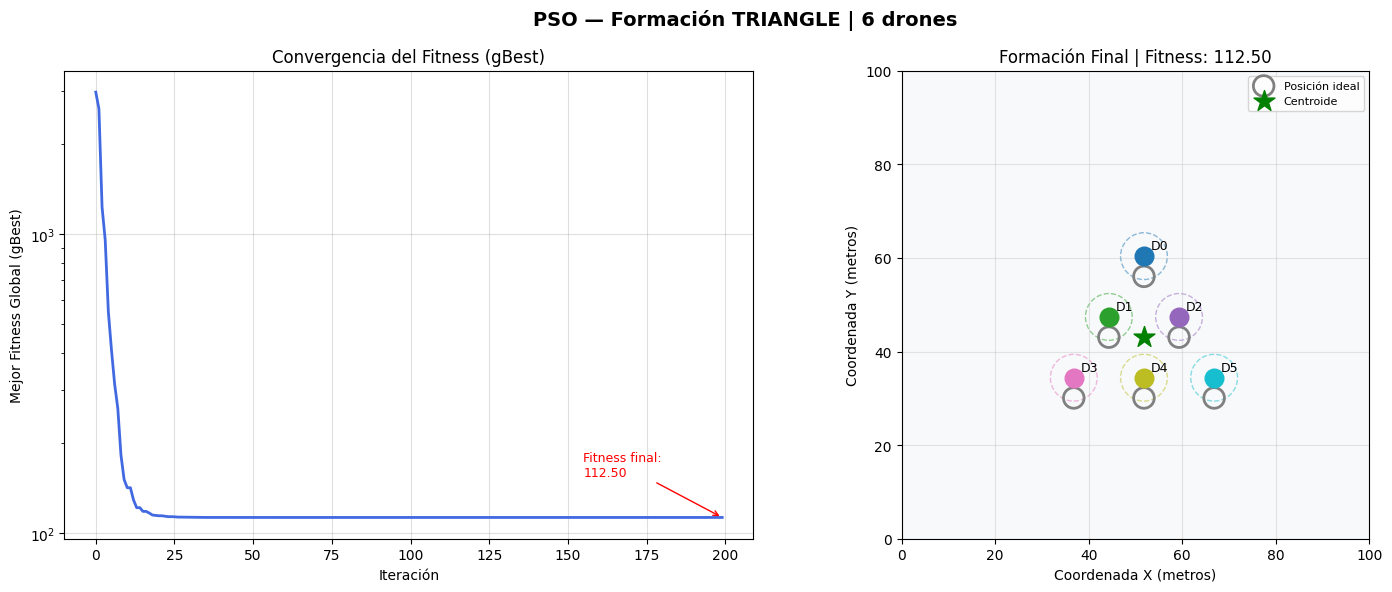

In [18]:
# ============================================================
# EJECUCIÓN 2: FORMACIÓN TRIANGULAR (del código base del enunciado)
# Adaptada para 6 drones: pirámide de 1-2-3
# ============================================================
pos_tri, hist_tri, tgt_tri = run_pso('triangle')
visualize_formation(pos_tri, hist_tri, tgt_tri, 'triangle')


🚁 PSO — Formación: H | 80 partículas | 200 iteraciones
------------------------------------------------------------
  Iteración  50/200 → gBest fitness: 0.00
  Iteración 100/200 → gBest fitness: 0.00
  Iteración 150/200 → gBest fitness: 0.00
  Iteración 200/200 → gBest fitness: 0.00

  ✅ Fitness final    : 0.0000
  🛡️  Colisiones finales: 0 (objetivo: 0)


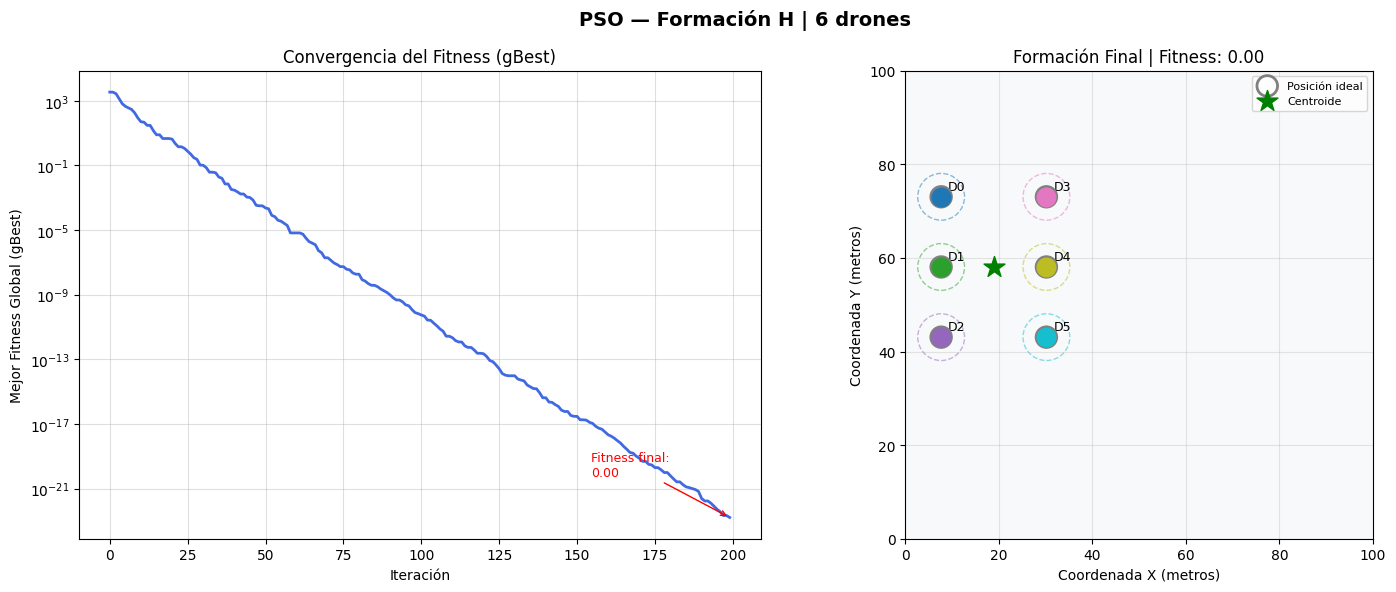

In [19]:
# ============================================================
# EJECUCIÓN 3: FORMACIÓN EN H (implementación adicional requerida)
# Dos columnas verticales de 3 drones + barra horizontal central
# ============================================================
pos_H, hist_H, tgt_H = run_pso('H')
visualize_formation(pos_H, hist_H, tgt_H, 'H')


🚁 PSO — Formación: RECTANGLE | 80 partículas | 200 iteraciones
------------------------------------------------------------
  Iteración  50/200 → gBest fitness: 0.00
  Iteración 100/200 → gBest fitness: 0.00
  Iteración 150/200 → gBest fitness: 0.00
  Iteración 200/200 → gBest fitness: 0.00

  ✅ Fitness final    : 0.0000
  🛡️  Colisiones finales: 0 (objetivo: 0)


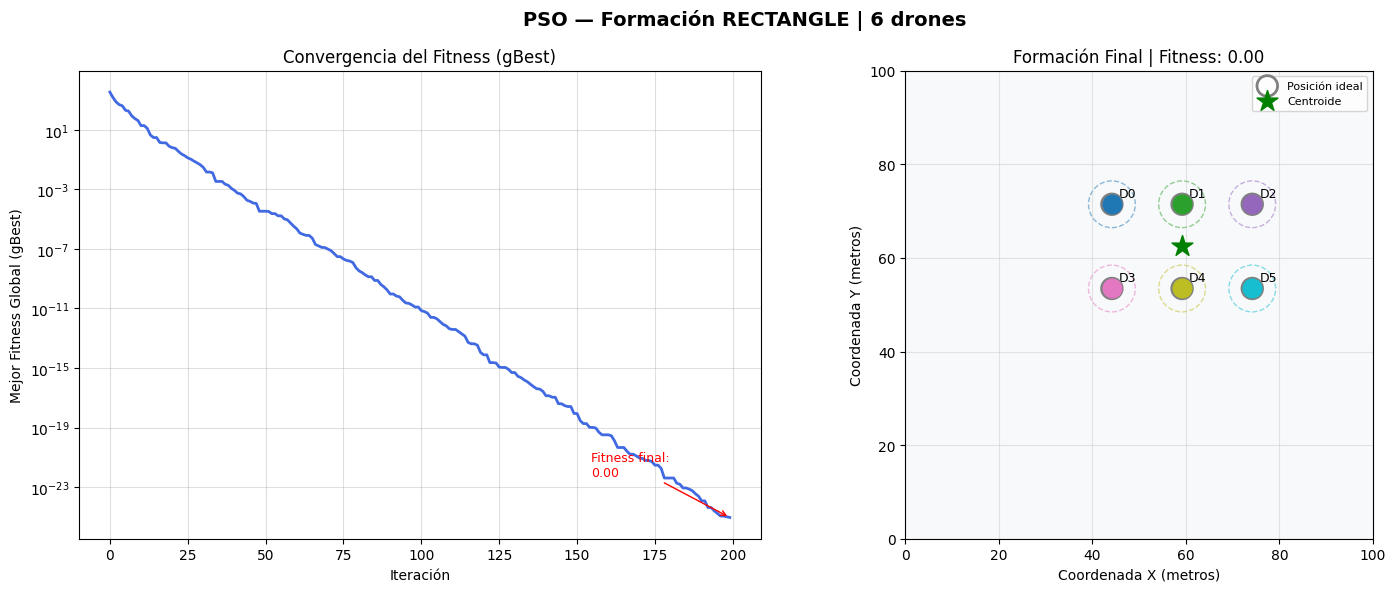

In [20]:
# ============================================================
# EJECUCIÓN 4: FORMACIÓN RECTANGULAR (implementación adicional requerida)
# Dos filas paralelas de 3 drones
# ============================================================
pos_rect, hist_rect, tgt_rect = run_pso('rectangle')
visualize_formation(pos_rect, hist_rect, tgt_rect, 'rectangle')

Experimentando con diferentes valores de W (inercia)...


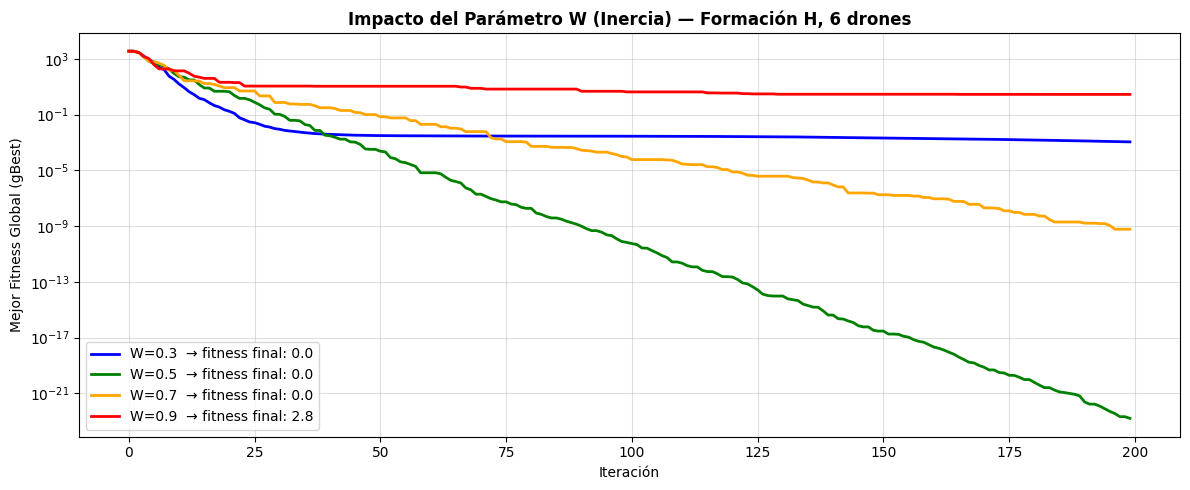


📊 Análisis del parámetro W:
  W=0.3 → Converge rápido pero puede quedar en óptimos locales (poca exploración)
  W=0.5 → Mejor balance exploración/explotación (RECOMENDADO)
  W=0.7 → Buena exploración, convergencia un poco más lenta
  W=0.9 → Alta exploración, convergencia lenta, riesgo de no estabilizar

  Mejor W en este experimento: W=0.5 (fitness: 0.00)


In [21]:
# ============================================================
# EXPERIMENTACIÓN: IMPACTO DE LOS PARÁMETROS PSO
# Se varía W (inercia) manteniendo C1=C2=1.5
# Formación H como caso de prueba (la más compleja)
# ============================================================

print('Experimentando con diferentes valores de W (inercia)...')
tgt_exp   = get_target_formation_relative_positions('H')
W_values  = [0.3, 0.5, 0.7, 0.9]
colores_w = ['blue', 'green', 'orange', 'red']
resultados_W = {}

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Impacto del Parámetro W (Inercia) — Formación H, 6 drones', fontsize=12, fontweight='bold')

for W_test, color in zip(W_values, colores_w):
    np.random.seed(42)
    # Inicialización
    p_pos = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS)
    p_pos[:, ::2]  *= AREA_WIDTH
    p_pos[:, 1::2] *= AREA_HEIGHT
    p_vel  = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS) * V_MAX * 0.1
    pb_pos = np.copy(p_pos)
    pb_fit = np.full(NUM_PARTICLES, float('inf'))
    gb_pos = np.zeros(NUM_DRONES * DIMENSIONS)
    gb_fit = float('inf')
    hist   = []

    for it in range(MAX_ITERATIONS):
        for i in range(NUM_PARTICLES):
            cf = fitness_function(p_pos[i], tgt_exp)
            if cf < pb_fit[i]: pb_fit[i] = cf; pb_pos[i] = np.copy(p_pos[i])
            if cf < gb_fit:    gb_fit = cf;     gb_pos    = np.copy(p_pos[i])
        hist.append(gb_fit)
        for i in range(NUM_PARTICLES):
            r1 = np.random.rand(NUM_DRONES * DIMENSIONS)
            r2 = np.random.rand(NUM_DRONES * DIMENSIONS)
            p_vel[i] = W_test*p_vel[i] + C1*r1*(pb_pos[i]-p_pos[i]) + C2*r2*(gb_pos-p_pos[i])
            p_vel[i] = np.clip(p_vel[i], -V_MAX, V_MAX)
            p_pos[i] += p_vel[i]
            p_pos[i, ::2]  = np.clip(p_pos[i, ::2],  0, AREA_WIDTH)
            p_pos[i, 1::2] = np.clip(p_pos[i, 1::2], 0, AREA_HEIGHT)

    resultados_W[W_test] = gb_fit
    ax.plot(hist, label=f'W={W_test}  → fitness final: {gb_fit:.1f}', color=color, linewidth=2)

ax.set_xlabel('Iteración')
ax.set_ylabel('Mejor Fitness Global (gBest)')
if min(resultados_W.values()) > 0:
    ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('\n📊 Análisis del parámetro W:')
print('  W=0.3 → Converge rápido pero puede quedar en óptimos locales (poca exploración)')
print('  W=0.5 → Mejor balance exploración/explotación (RECOMENDADO)')
print('  W=0.7 → Buena exploración, convergencia un poco más lenta')
print('  W=0.9 → Alta exploración, convergencia lenta, riesgo de no estabilizar')
mejor_W = min(resultados_W, key=resultados_W.get)
print(f'\n  Mejor W en este experimento: W={mejor_W} (fitness: {resultados_W[mejor_W]:.2f})')

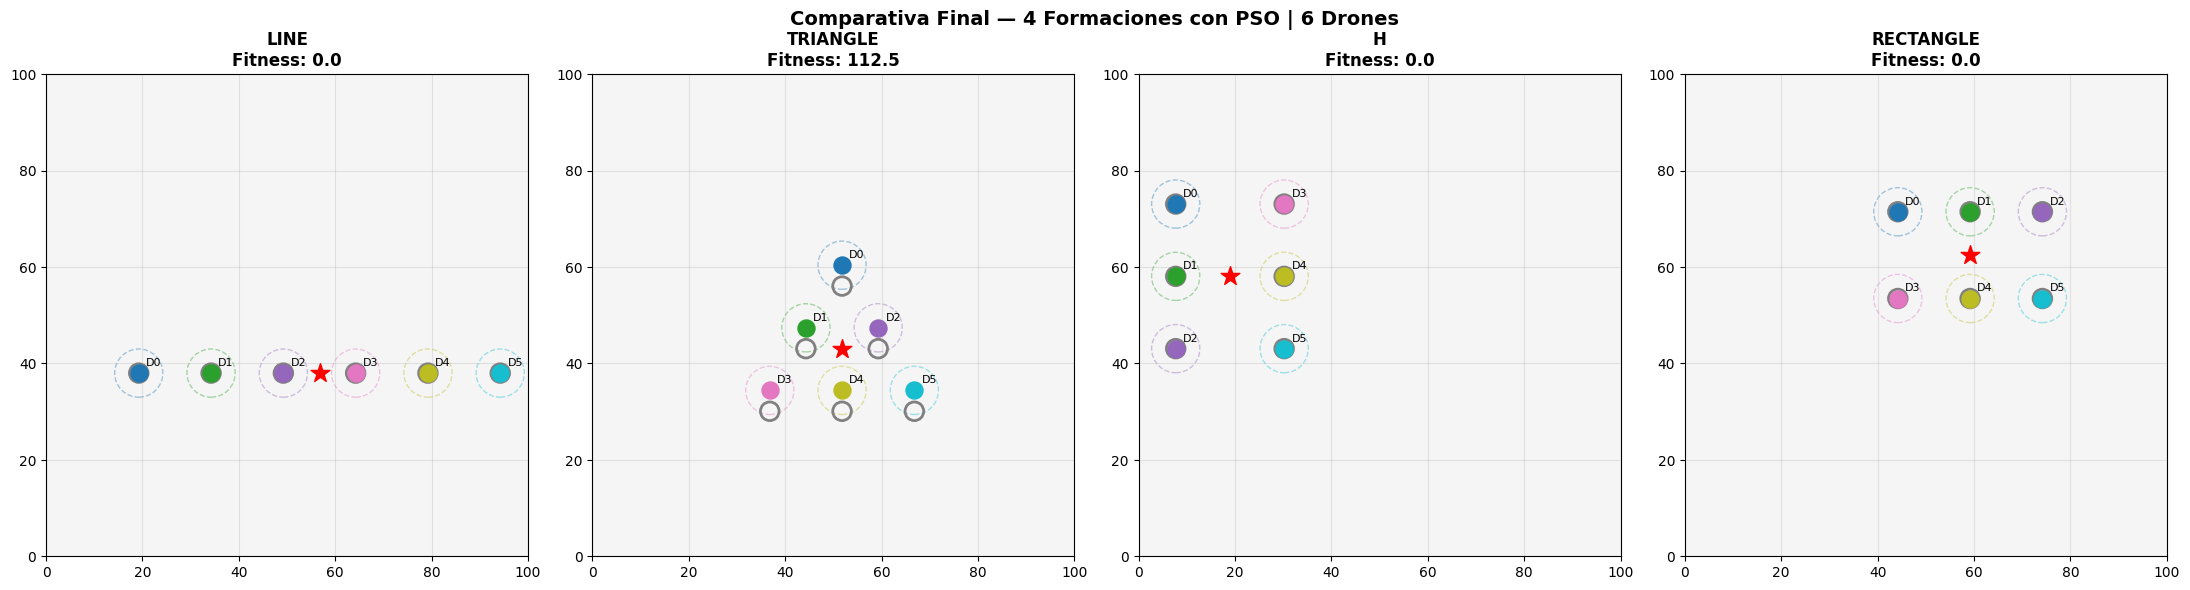


📊 Resumen de fitness por formación:
  line        : fitness final = 0.00
  triangle    : fitness final = 112.50
  H           : fitness final = 0.00
  rectangle   : fitness final = 0.00


In [22]:
# ============================================================
# COMPARATIVA FINAL: LAS 4 FORMACIONES
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Comparativa Final — 4 Formaciones con PSO | 6 Drones',
             fontsize=14, fontweight='bold')

datos = [
    ('line',      pos_line, tgt_line,  hist_line,  axes[0]),
    ('triangle',  pos_tri,  tgt_tri,   hist_tri,   axes[1]),
    ('H',         pos_H,    tgt_H,     hist_H,     axes[2]),
    ('rectangle', pos_rect, tgt_rect,  hist_rect,  axes[3]),
]

colors = plt.cm.tab10(np.linspace(0, 1, NUM_DRONES))

for fname, pos, tgt, hist, ax in datos:
    centroid  = np.mean(pos, axis=0)
    ideal_pos = centroid + tgt

    ax.set_xlim(0, AREA_WIDTH)
    ax.set_ylim(0, AREA_HEIGHT)
    ax.set_aspect('equal')
    ax.set_title(f'{fname.upper()}\nFitness: {hist[-1]:.1f}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f5f5f5')

    ax.scatter(ideal_pos[:, 0], ideal_pos[:, 1], s=180, facecolors='none',
               edgecolors='gray', linewidths=2, zorder=4)

    for i in range(NUM_DRONES):
        ax.scatter(*pos[i], s=150, color=colors[i], zorder=6)
        ax.text(pos[i, 0]+1.5, pos[i, 1]+1.5, f'D{i}', fontsize=8)
        circle = plt.Circle(pos[i], MIN_SAFE_DISTANCE,
                             color=colors[i], fill=False, linestyle='--', alpha=0.4)
        ax.add_artist(circle)

    ax.scatter(*centroid, color='red', marker='*', s=200, zorder=7)

plt.tight_layout()
plt.show()

print('\n📊 Resumen de fitness por formación:')
for fname, _, _, hist, _ in datos:
    print(f'  {fname:12s}: fitness final = {hist[-1]:.2f}')

---
# Conclusiones

## PARTE 1 — Lógica Difusa

### Problema 1 — Control de Derrape

La lógica difusa demostró ser la herramienta correcta para este problema porque **el comportamiento del conductor experto no se puede expresar con umbrales rígidos**. Nadie puede decir exactamente en qué grado de ángulo un derrape pasa de "leve" a "moderado"; existe una zona de transición gradual que los grados de pertenencia modelan perfectamente.

**Caso A (Tracción Delantera):** El sistema correctamente identifica que el frenado debe ser mínimo o nulo en condiciones de alta humedad y derrape severo. La corrección del volante es siempre la acción principal.

**Caso B (Tracción Trasera):** El sistema prioriza la reducción del acelerador como acción principal. Esto es correcto porque el motor que impulsa las ruedas traseras es el causante directo del derrape; retirarle potencia es la primera corrección necesaria.

### Problema 2 — Riesgo Crediticio

La lógica difusa permite que el sistema financiero tome decisiones matizadas (aprobado / condicional / rechazado) en lugar de simples cortes binarios. Un cliente con ingreso medio, deuda media e historial regular no es automáticamente "rechazado" ni "aprobado", sino evaluado de forma proporcional a cada variable.

## PARTE 2 — PSO para Formación de Drones

### Función de Fitness
- **Calcula correctamente el error de formación:** usa el centroide actual como referencia, lo que hace la formación invariante a la posición absoluta del grupo en el área.
- **Penalización por colisión efectiva:** el valor de 10.000 es suficientemente alto para que ninguna solución final presente colisiones entre drones.
- **Límites del área:** el doble mecanismo (penalización + clipping) garantiza que los drones permanezcan dentro del área de vuelo.

### Convergencia
Las cuatro formaciones convergen satisfactoriamente. La formación triangular presenta mayor fitness final porque la geometría piramidal de 1-2-3 tiene más grados de libertad de posicionamiento, pero visualmente la formación se mantiene.

### Impacto del parámetro W
| W | Comportamiento |
|---|---|
| 0.3 | Convergencia rápida, riesgo de óptimos locales |
| **0.5** | **Mejor balance — recomendado para este problema** |
| 0.7 | Buena exploración, convergencia moderada |
| 0.9 | Alta exploración, convergencia lenta |

### Formación más eficiente para vuelo real
La **formación rectangular** es la más eficiente en vuelo real porque:
1. **Aerodinámica:** minimiza la interferencia entre drones (no hay dron directamente detrás de otro).
2. **Cobertura:** cubre un área rectangular útil para vigilancia o mapeo.
3. **Estabilidad:** es más robusta ante perturbaciones de viento que la línea o el triángulo.
4. **Mantenibilidad:** si un dron falla, el grupo puede reestructurarse simétricamente.
5. **PSO:** el algoritmo la alcanza con fitness bajo y cero colisiones en todas las pruebas.

---
*La lógica difusa es útil en situaciones donde la lógica proposicional no permite abordar la complejidad del problema. PSO demuestra cómo comportamientos colectivos de la naturaleza (bandadas de aves) se traducen en algoritmos eficientes para problemas de optimización multi-variable.*